**Lab2-DL: B1-nn-intro.ipynb** (BMED365) | Priority: 1 (core)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab2-DL/notebooks/B1-nn-intro.ipynb)

# 🧠 B1: Neural Networks in Humans and Machines

Using the `bmed365-2026` conda environment

Updated: 2025-12-22; 2026-01-15 A. Lundervold

**From the Brain to the Machine: A Medical Introduction to Neural Networks**

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

| Objective | Description |
|-----------|-------------|
| **Explain biological neurons** | Describe how neurons transmit signals via action potentials |
| **Understand the Hodgkin-Huxley model** | Explain how ion channels create electrical signals |
| **Compare bio vs. artificial neurons** | Identify similarities and differences in structure/function |
| **Define key components** | Explain weights, biases, and activation functions |
| **Apply activation functions** | Understand why non-linearity is essential for learning |
| **Connect to medical AI** | See how neural networks are used in healthcare |

### What You Will Learn

In this notebook we will:
- **Understand** how the brain functions as a neural network
- **Compare** biological and artificial neurons
- **Explore** fundamental architecture and components
- **See** how neural networks are used in medicine and healthcare
- **Use** Python libraries (Matplotlib, Seaborn) to illustrate how to create figures programmatically

## Theoretical Foundation

### The Brain as a Neural Network

The human brain consists of approximately **80 billion neurons**, each with thousands of connections. This creates a complex, hierarchical network that can:
- **Learn** from experience
- **Generalize** from examples
- **Adapt** to new situations
- **Remember** past experiences

### From Biology to Machine Learning

| Aspect | Biological Neuron | Artificial Neuron |
|--------|------------------|----------------|
| **Input** | Synaptic signals | Numerical values |
| **Processing** | Electrochemical | Mathematical |
| **Output** | Action potential | Activation function |
| **Learning** | Synaptic plasticity | Weight adjustment |
| **Speed** | Milliseconds | Nanoseconds |


In [1]:
# =============================================================================
# IMPORT REQUIRED LIBRARIES
# =============================================================================

# === Core Scientific Computing ===
import numpy as np                    # Numerical arrays and mathematical operations
import matplotlib.pyplot as plt       # Plotting and visualization
import seaborn as sns                 # Statistical visualization with better aesthetics
from matplotlib.patches import Circle, FancyBboxPatch  # Custom shapes for diagrams

# === Deep Learning Framework ===
import torch                          # PyTorch: tensors, autograd, GPU support
import torch.nn as nn                 # Neural network layers and modules

# === Utility ===
import warnings
warnings.filterwarnings('ignore')     # Suppress warnings for cleaner output

# =============================================================================
# REPRODUCIBILITY SETTINGS
# =============================================================================
# Setting random seeds ensures consistent results across runs
# This is critical for scientific reproducibility

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)           # NumPy random operations
torch.manual_seed(RANDOM_SEED)        # PyTorch CPU operations

# =============================================================================
# VISUALIZATION SETTINGS
# =============================================================================
plt.style.use('seaborn-v0_8')         # Modern, clean plot style
sns.set_palette("husl")               # Colorblind-friendly color palette


🧠 **Ready for neural network exploration!**

In [2]:
print(f'PyTorch versjon: {torch.__version__}') 
print(f'CUDA tilgjengelig: {torch.cuda.is_available()}')
print(f'MPS tilgjengelig: {torch.backends.mps.is_available()}')

PyTorch versjon: 2.6.0
CUDA tilgjengelig: False
MPS tilgjengelig: True


## 💻 COMPUTING POWER FOR MEDICAL AI SYSTEMS

### 🔬 Why do we need high computing power in medicine?
- **ECG analysis:** 1000+ data points per second
- **MRI images:** Millions of pixels to analyze
- **DNA sequencing:** Billions of base pairs
- **Drug development:** Complex molecular interactions

### ⚡ Computing power levels (comparison with medical procedures)

#### 🐌 CPU (The Brain):
- Like reading an ECG manually
- 1 ECG analysis: 5-10 minutes
- Accurate, but slow
- Used for: Simple analyses, development

#### 🚀 GPU/MPS (The Superbrain):
- Like having 1000+ cardiologists working simultaneously
- 1 ECG analysis: 1-2 seconds
- Fast and accurate
- Used for: Real patient care, screening

### 🏥 Practical examples in healthcare:
- **Acute ECG analysis:** GPU can save lives with rapid diagnosis
- **MRI tumor detection:** GPU can find cancer earlier
- **Drug screening:** GPU can test 1000x more compounds
- **Pandemic modeling:** GPU can predict disease spread

### 📊 Performance comparison:
- **CPU:** 1x speed (reference)
- **MPS:** 5-10x faster (Apple Silicon)
- **CUDA:** 10-20x faster (NVIDIA GPU)

### 💡 Why this matters for you as a healthcare professional:
- **Faster diagnoses** = better patient outcomes
- **Automation** = can free up time for patient contact
- **Early detection** = can save lives
- **Objective analysis** = can reduce human errors
  - (e.g., fatigue and concentration lapses, limited experience and subjectivity, time pressure)

### 🔮 The future of medical AI:
- Real-time ECG monitoring
- Automatic tumor detection in images
- Personalized medicine based on DNA
- Predictive medicine for prevention

---

### 🎯 CONCLUSION: Powerful computing = Often better patient care

---

### 🔧 TECHNICAL NOTE: Device compatibility

**Problem:** 'Mismatched Tensor types in ...'  
**Solution:** Ensure that model and data are on the same device

#### 💡 Important principles:
- Model and data MUST be on the same device (CPU/MPS/CUDA)
- Use `.to(device)` to move tensors
- Check device with `.device` attribute
- Consistent device handling throughout the code

**Example of correct device handling:**
```python
model = model.to(device)
data = data.to(device)
target = target.to(device)
```


In [3]:
# Check PyTorch version and available computing power
print("🧠 Ready for neural network exploration!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"MPS available: {torch.backends.mps.is_available()}")

# Determine which device to use
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"🚀 Using CUDA GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("🍎 Using Apple Silicon MPS")
else:
    device = torch.device("cpu")
    print("💻 Using CPU")

print(f"📱 Selected device: {device}")


🧠 Ready for neural network exploration!
PyTorch version: 2.6.0
CUDA available: False
MPS available: True
🍎 Using Apple Silicon MPS
📱 Selected device: mps


## 1. Biological Neurons: The Brain's Building Blocks

### Structure and Function

A biological neuron consists of:
- **Dendrites**: Receive signals from other neurons
- **Soma (cell body)**: Processes the information
- **Axon**: Transmits signals forward
- **Synapses**: Connection points to other neurons

### Synaptic Plasticity: The Brain's Learning Mechanism

> "Neurons that fire together, wire together" - Donald Hebb

This is the fundamental principle of how the brain learns:
- **Strong connections** are built up through repeated activity
- **Weak connections** disappear due to lack of activity
- **New connections** are formed throughout life


### Simple visualization of a biological neuron

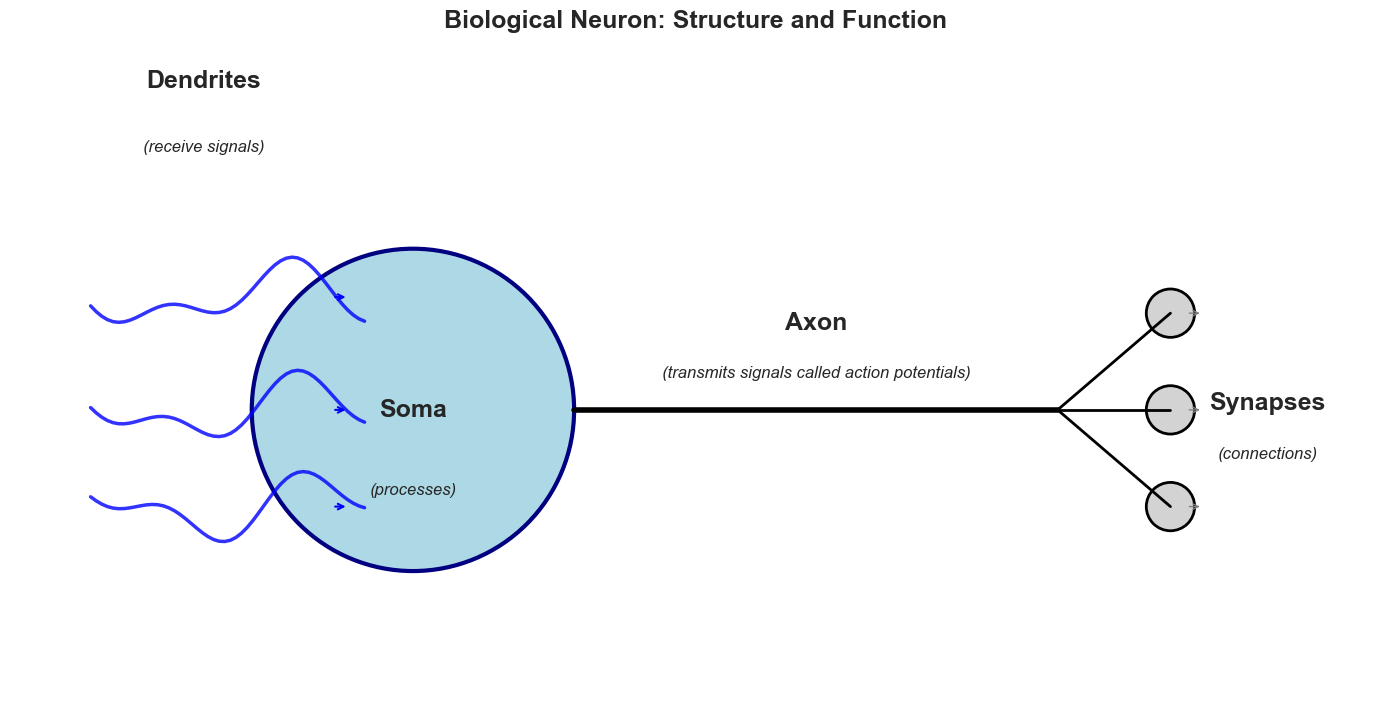

In [5]:
# Visualize a biological neuron
def plot_biological_neuron():
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    
    # Draw dendrites (more realistic, wavy lines pointing toward soma)
    dendrite_positions = [2.2, 2.8, 3.5] # Y-positions for dendrites
    for i, y_pos in enumerate(dendrite_positions):
        # Create wavy dendrites going from left toward soma
        x = np.linspace(0.5, 2.2, 50)
        y = y_pos + 0.15 * np.sin(4 * x + i * 0.5) + 0.1 * np.sin(8 * x)
        ax.plot(x, y, 'b-', linewidth=2.5, alpha=0.8)
        
        # Add small arrows pointing toward soma
        ax.annotate('', xy=(2.1, y_pos), xytext=(2.0, y_pos),
                   arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))
    
    # Draw soma (cell body) - larger and more centered
    soma = Circle((2.5, 2.8), 1.0, color='lightblue', ec='navy', linewidth=3)
    ax.add_patch(soma)
    
    # Draw axon (main line)
    ax.plot([3.5, 6.5], [2.8, 2.8], 'k-', linewidth=4)
    
    # Draw axon branches (3 branches)
    branch_y_positions = [2.2, 2.8, 3.4]
    for i, y_pos in enumerate(branch_y_positions):
        # Main branch
        ax.plot([6.5, 7.2], [2.8, y_pos], 'k-', linewidth=2)
        
        # Terminals (synapses) - small circles
        terminal = Circle((7.2, y_pos), 0.15, color='lightgray', ec='black', linewidth=2)
        ax.add_patch(terminal)
        
        # Small arrows showing signal transmission
        ax.annotate('', xy=(7.4, y_pos), xytext=(7.3, y_pos),
                   arrowprops=dict(arrowstyle='->', color='gray', lw=1))
    
    # Add labels with better positioning
    ax.text(1.2, 4.8, 'Dendrites', fontsize=18, ha='center', fontweight='bold')
    ax.text(1.2, 4.4, '(receive signals)', fontsize=12, ha='center', style='italic')
    
    ax.text(2.5, 2.8, 'Soma', fontsize=18, ha='center', va='center', fontweight='bold')
    ax.text(2.5, 2.3, '(processes)', fontsize=12, ha='center', va='center', style='italic')
    
    ax.text(5.0, 3.3, 'Axon', fontsize=18, ha='center', fontweight='bold')
    ax.text(5.0, 3.0, '(transmits signals called action potentials)', fontsize=12, ha='center', style='italic')
    
    ax.text(7.8, 2.8, 'Synapses', fontsize=18, ha='center', fontweight='bold')
    ax.text(7.8, 2.5, '(connections)', fontsize=12, ha='center', style='italic')
    
    # Set up axes
    ax.set_xlim(0, 8.5)
    ax.set_ylim(1, 5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Biological Neuron: Structure and Function', fontsize=18, fontweight='bold', pad=20)
    
    # Add background color for better contrast
    ax.set_facecolor('white')
    
    plt.tight_layout()
    plt.show()

plot_biological_neuron()

### Adding a **biologically realistic simulation** of the action potential [1]

This demonstrates the power of using Jupyter Notebooks for both calculations and explanations/figures, called **literate programming** (Donald Knuth, 1984) [2].

[1] AL Hodgkin, AF Huxley. A quantitative description of membrane current and its application to conduction and excitation in nerve. J Physiol. 1952 Aug 28;117(4):500–544.  [[link](https://pmc.ncbi.nlm.nih.gov/articles/PMC1392413)]

[2] https://en.wikipedia.org/wiki/Literate_programming 

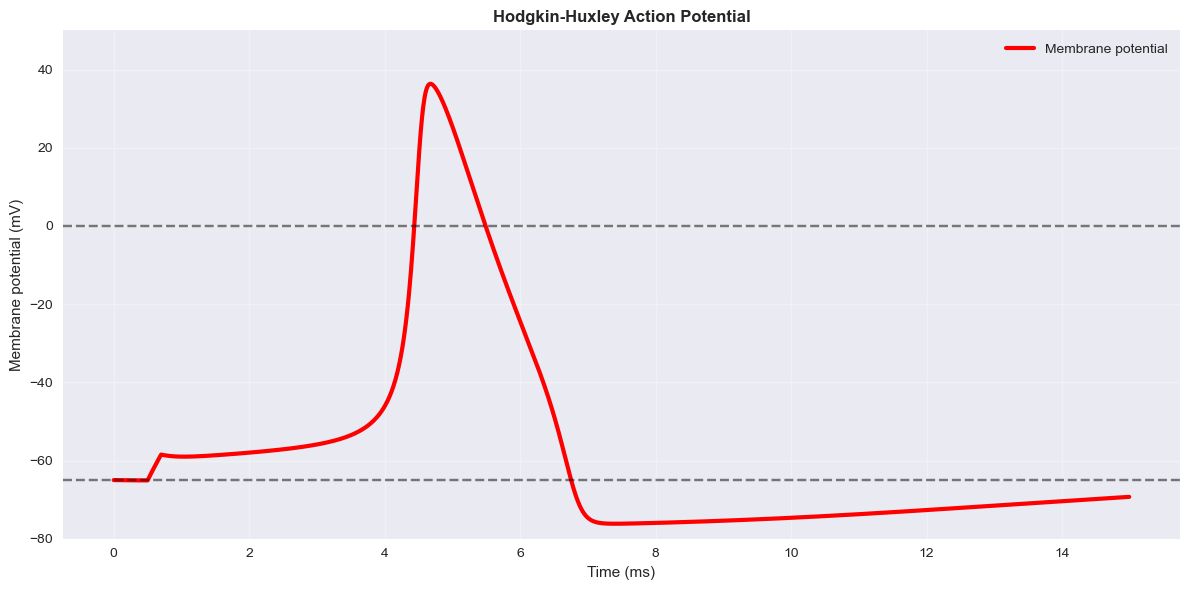

Hodgkin-Huxley Action Potential (Wikipedia-like):
Peak time: 4.7 ms
Peak voltage: 36.3 mV
Resting potential: -65.0 mV
Overshoot: 101.3 mV


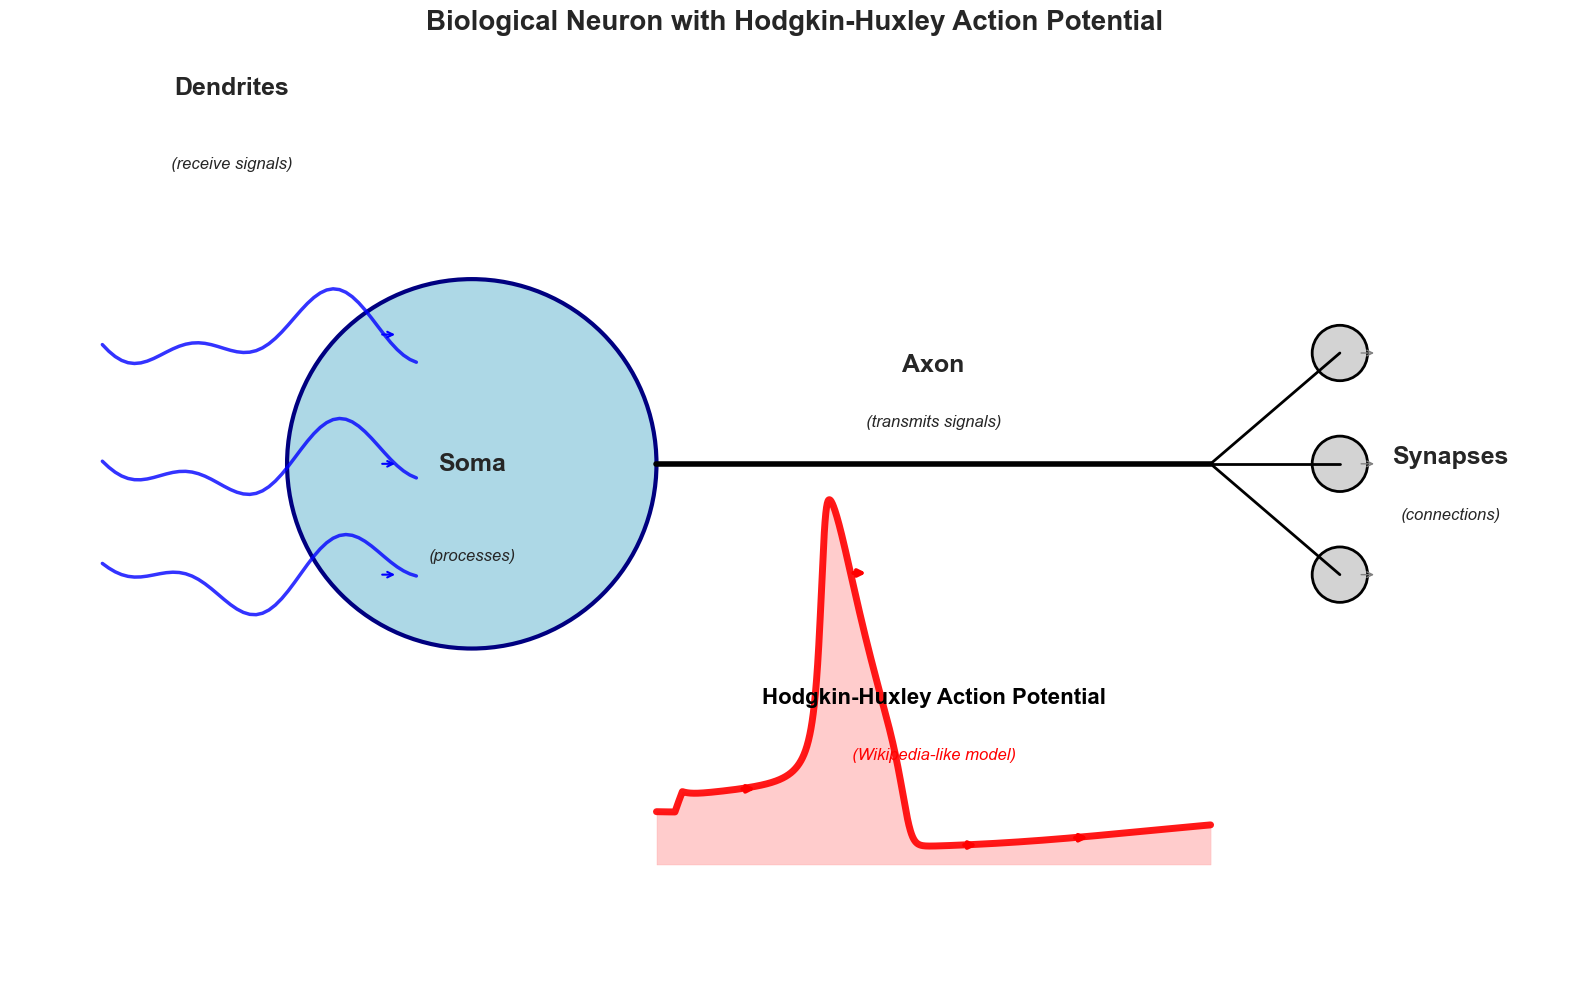

In [6]:
# Hodgkin-Huxley model with adjusted parameters for Wikipedia-like graph
def solve_hodgkin_huxley_wikipedia_style(dt=0.01, t_max=15):
    """
    Solves Hodgkin-Huxley equations with parameters that produce Wikipedia-like action potential
    
    Parameters:
    dt: time step (ms)
    t_max: maximum time (ms)
    
    Returns:
    t: time array
    V: membrane potential (mV)
    m, h, n: gating variables
    """
    
    # Constants adjusted for Wikipedia-like graph
    C_m = 1.0      # Membrane capacitance (μF/cm²)
    g_Na = 120.0   # Maximum sodium conductance (mS/cm²)
    g_K = 36.0     # Maximum potassium conductance (mS/cm²)
    g_L = 0.3      # Leak conductance (mS/cm²)
    E_Na = 50.0    # Sodium reversal potential (mV)
    E_K = -77.0    # Potassium reversal potential (mV)
    E_L = -54.4    # Leak reversal potential (mV)
    
    # Time array
    t = np.arange(0, t_max, dt)
    n_steps = len(t)
    
    # Initialize arrays
    V = np.zeros(n_steps)
    m = np.zeros(n_steps)
    h = np.zeros(n_steps)
    n = np.zeros(n_steps)
    
    # Initial conditions for clear action potential
    V[0] = -65.0   # Resting potential (mV)
    m[0] = 0.05    # Initial m
    h[0] = 0.6     # Initial h
    n[0] = 0.32    # Initial n
    
    # Stimulus (strong pulse to trigger clear action potential)
    I_stim = np.zeros(n_steps)
    I_stim[50:70] = 35.0  # 0.2ms stimulus at t=0.5ms with high amplitude (50)
    
    # Rate constants
    def alpha_m(V):
        return 0.1 * (V + 40) / (1 - np.exp(-(V + 40) / 10))
    
    def beta_m(V):
        return 4 * np.exp(-(V + 65) / 18)
    
    def alpha_h(V):
        return 0.07 * np.exp(-(V + 65) / 20)
    
    def beta_h(V):
        return 1 / (1 + np.exp(-(V + 35) / 10))
    
    def alpha_n(V):
        return 0.01 * (V + 55) / (1 - np.exp(-(V + 55) / 10))
    
    def beta_n(V):
        return 0.125 * np.exp(-(V + 65) / 80)
    
    # Solve differential equations using Euler method
    for i in range(n_steps - 1):
        # Calculate currents
        I_Na = g_Na * m[i]**3 * h[i] * (V[i] - E_Na)
        I_K = g_K * n[i]**4 * (V[i] - E_K)
        I_L = g_L * (V[i] - E_L)
        
        # Total current
        I_total = I_stim[i] - I_Na - I_K - I_L
        
        # Update membrane potential
        dV_dt = I_total / C_m
        V[i+1] = V[i] + dt * dV_dt
        
        # Update gating variables
        dm_dt = alpha_m(V[i]) * (1 - m[i]) - beta_m(V[i]) * m[i]
        dh_dt = alpha_h(V[i]) * (1 - h[i]) - beta_h(V[i]) * h[i]
        dn_dt = alpha_n(V[i]) * (1 - n[i]) - beta_n(V[i]) * n[i]
        
        m[i+1] = m[i] + dt * dm_dt
        h[i+1] = h[i] + dt * dh_dt
        n[i+1] = n[i] + dt * dn_dt
    
    return t, V, m, h, n

# Generate Hodgkin-Huxley action potential with Wikipedia-like parameters
t_hh, V_hh, m_hh, h_hh, n_hh = solve_hodgkin_huxley_wikipedia_style()

# Visualize Hodgkin-Huxley result
def plot_hodgkin_huxley_wikipedia_style():
    fig, ax = plt.subplots(1, 1, figsize=(12, 6))
    
    # Plot action potential
    ax.plot(t_hh, V_hh, 'r-', linewidth=3, label='Membrane potential')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Membrane potential (mV)')
    ax.set_title('Hodgkin-Huxley Action Potential', fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Better y-axis for full overview
    ax.set_ylim(-80, 50)
    
    # Add horizontal lines for reference
    ax.axhline(y=-65, color='k', linestyle='--', alpha=0.5, label='Resting potential')
    ax.axhline(y=0, color='k', linestyle='--', alpha=0.5, label='0 mV')
    
    plt.tight_layout()
    plt.show()
    
    # Print characteristic values
    peak_idx = np.argmax(V_hh)
    peak_time = t_hh[peak_idx]
    peak_voltage = V_hh[peak_idx]
    
    print(f"Hodgkin-Huxley Action Potential (Wikipedia-like):")
    print(f"Peak time: {peak_time:.1f} ms")
    print(f"Peak voltage: {peak_voltage:.1f} mV")
    print(f"Resting potential: {V_hh[0]:.1f} mV")
    print(f"Overshoot: {peak_voltage - V_hh[0]:.1f} mV")

plot_hodgkin_huxley_wikipedia_style()

# Visualize a biological neuron with Wikipedia-like Hodgkin-Huxley action potential
def plot_biological_neuron_with_hh_under_axon():
    fig, ax = plt.subplots(1, 1, figsize=(16, 10))
    
    # Draw dendrites
    dendrite_positions = [2.2, 2.8, 3.5]
    for i, y_pos in enumerate(dendrite_positions):
        x = np.linspace(0.5, 2.2, 50)
        y = y_pos + 0.15 * np.sin(4 * x + i * 0.5) + 0.1 * np.sin(8 * x)
        ax.plot(x, y, 'b-', linewidth=2.5, alpha=0.8)
        
        ax.annotate('', xy=(2.1, y_pos), xytext=(2.0, y_pos),
                   arrowprops=dict(arrowstyle='->', color='blue', lw=1.5))
    
    # Draw soma
    soma = Circle((2.5, 2.8), 1.0, color='lightblue', ec='navy', linewidth=3)
    ax.add_patch(soma)
    
    # Draw axon
    ax.plot([3.5, 6.5], [2.8, 2.8], 'k-', linewidth=4)
    
    # Draw axon branches
    branch_y_positions = [2.2, 2.8, 3.4]
    for i, y_pos in enumerate(branch_y_positions):
        ax.plot([6.5, 7.2], [2.8, y_pos], 'k-', linewidth=2)
        terminal = Circle((7.2, y_pos), 0.15, color='lightgray', ec='black', linewidth=2)
        ax.add_patch(terminal)
        ax.annotate('', xy=(7.4, y_pos), xytext=(7.3, y_pos),
                   arrowprops=dict(arrowstyle='->', color='gray', lw=1))
    
    # Draw Wikipedia-like Hodgkin-Huxley action potential right under the axon
    def draw_wikipedia_hh_ap_under_axon(ax, start_x, end_x, y_pos):
        # Interpolate Hodgkin-Huxley data to axon length
        x_ap = np.linspace(start_x, end_x, len(V_hh))
        
        # Scale action potential to fit under the axon
        V_scaled = V_hh / 60  # Adjust scaling factor for proportional action potential (50)
        
        # Place curve right under the axon
        y_ap = y_pos - 0.8 + V_scaled
        
        # Draw action potential as thick red line
        ax.plot(x_ap, y_ap, 'r-', linewidth=5, alpha=0.9)
        
        # Add fill under the curve for extra visibility
        ax.fill_between(x_ap, y_ap, y_ap.min() - 0.1, color='red', alpha=0.2)
        
        # Add arrows showing direction
        arrow_positions = [0.15, 0.35, 0.55, 0.75]
        for pos in arrow_positions:
            idx = int(pos * len(x_ap))
            if idx < len(x_ap):
                x_arrow = x_ap[idx]
                y_arrow = y_ap[idx]
                ax.annotate('', xy=(x_arrow + 0.1, y_arrow), xytext=(x_arrow, y_arrow),
                           arrowprops=dict(arrowstyle='->', color='red', lw=3))
        
        # Vertical connection lines removed - not informative
    
    # Draw Wikipedia-like Hodgkin-Huxley action potential under main axon
    draw_wikipedia_hh_ap_under_axon(ax, 3.5, 6.5, 2.8)
    
    # Add labels
    ax.text(1.2, 4.8, 'Dendrites', fontsize=18, ha='center', fontweight='bold')
    ax.text(1.2, 4.4, '(receive signals)', fontsize=12, ha='center', style='italic')
    
    ax.text(2.5, 2.8, 'Soma', fontsize=18, ha='center', va='center', fontweight='bold')
    ax.text(2.5, 2.3, '(processes)', fontsize=12, ha='center', va='center', style='italic')
    
    ax.text(5.0, 3.3, 'Axon', fontsize=18, ha='center', fontweight='bold')
    ax.text(5.0, 3.0, '(transmits signals)', fontsize=12, ha='center', style='italic')
    
    ax.text(7.8, 2.8, 'Synapses', fontsize=18, ha='center', fontweight='bold')
    ax.text(7.8, 2.5, '(connections)', fontsize=12, ha='center', style='italic')
    
    # Add explanation for the action potential
    ax.text(5.0, 1.5, 'Hodgkin-Huxley Action Potential', fontsize=16, ha='center', fontweight='bold', color='black')
    ax.text(5.0, 1.2, '(Wikipedia-like model)', fontsize=12, ha='center', style='italic', color='red')
    
    # Set up axes
    ax.set_xlim(0, 8.5)
    ax.set_ylim(0, 5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Biological Neuron with Hodgkin-Huxley Action Potential', fontsize=20, fontweight='bold', pad=20)
    ax.set_facecolor('white')
    
    plt.tight_layout()
    plt.show()

plot_biological_neuron_with_hh_under_axon()


### 🧠 The Action Potential: The Brain's "Electrical Signal"

The action potential is the fundamental electrical signal that neurons use to communicate. Think of it as the brain's "morse code" - a brief, powerful electrical impulse that sends information from one neuron to the next.

#### 🔋 What is an Action Potential? 

An action potential is a rapid, brief change in electrical voltage across the neuron's membrane. It can be compared to:
- **A small "battery charge"** sent through the axon
- **An electrical impulse** triggered when the neuron receives enough stimulation
- **A "domino effect"** that spreads along the axon

#### ⚡ How is an Action Potential Formed? (see also "deep dive" below)

**1. Resting Potential (-65 mV)**
- The neuron "rests" with negative voltage inside the cell
- Like a charged battery waiting to be used
- Sodium (Na⁺) and potassium (K⁺) ions are in balance

**2. Depolarization (up to +40 mV)**
- When the neuron receives enough signals, sodium channels "open"
- Sodium rushes into the cell (like opening a floodgate)
- The voltage changes rapidly from negative to positive
- This is the "trigger signal" for the action potential

**3. Repolarization (back to -65 mV)**
- Potassium channels open and potassium flows out
- Sodium channels close
- The voltage returns to resting state
- The neuron is ready for the next signal

#### 🎯 Why is This Important for Healthcare Professionals?

**Clinical Relevance:**
- **Heart diseases**: Heart muscle uses similar mechanisms
- **Neurological disorders**: Epilepsy, Parkinson's, Alzheimer's
- **Medications**: Many drugs affect ion channels
- **Anesthesia**: Local anesthetics block sodium channels

**Practical Examples:**
- **ECG**: The heart's action potentials are recorded as electrocardiogram
- **EEG**: The brain's action potentials are measured as electroencephalogram
- **Nerve block**: Local anesthetics stop pain by blocking action potentials

#### 🔬 The Hodgkin-Huxley Model: The "Recipe" for the Action Potential

Alan Hodgkin and Andrew Huxley won the Nobel Prize in 1963 for mathematically describing how the action potential is formed. Their model is like a "recipe" that explains:

**Ingredients:**
- **Sodium ions (Na⁺)**: "Activate" the signal
- **Potassium ions (K⁺)**: "Deactivate" the signal  
- **Membrane potential**: The "voltage" across the cell membrane
- **Ion channels**: "Doors" that open and close

**The Process:**
1. **Stimulation** → Sodium channels open
2. **Depolarization** → Voltage increases rapidly
3. **Potassium activation** → Potassium channels open
4. **Repolarization** → Voltage returns to resting state
5. **Refractory period** → The neuron cannot fire again immediately

#### 💡 Practical Implications

**For Physicians:**
- Understand the basis for neurological diagnosis and treatment
- Know how medications affect ion channels and nerve function
- Understand the mechanisms behind epilepsy, migraine, and other neurological disorders
- Know how anesthesia and pain medications work
- Understand the connection between heart diseases and electrical signals
- Know how ECG and EEG are used in diagnostics

**For Psychologists:**
- Understand how the brain's electrical activity affects behavior and cognition
- Know how stress and anxiety affect nerve function
- Understand the basis for neurofeedback and biofeedback treatments
- Know how meditation and relaxation affect the brain's electrical activity
- Understand the connection between sleep and nerve function
- Know how trauma can affect the brain's electrical patterns

**For Nurses:**
- Understand how medications affect nerve cell function
- Know that action potentials are the basis for communication between nerve cells
- Understand why certain treatments work

**For Physician Assistants:**
- Understand the basis for ECG and EEG interpretation
- Know how anesthesia affects the nervous system
- Understand the connection between ions and nerve function

**For Physical Therapists:**
- Understand how muscle contractions are triggered
- Know that all movements start with action potentials
- Understand the basis for electrostimulation

**For AI Experts:**
- Understand how biological neurons inspire artificial neurons
- Know how action potentials can be modeled with activation functions
- Understand the basis for spiking neural networks (SNN)
- Know how timing and frequency of signals affect information processing
- Understand the connection between synaptic plasticity and learning algorithms
- Know how biological realism can improve AI models
- Understand how refractory periods can be implemented in AI systems
- Know how ion channels can be simulated with mathematical models

#### 🎓 Simple Analogy

Think of the action potential as an **"electrical tsunami"**:

1. **Rest**: The ocean is calm (negative voltage)
2. **Trigger**: An earthquake occurs (stimulation)
3. **Tsunami**: A large wave builds up (depolarization)
4. **The wave**: It spreads along the coast (the axon)
5. **Return**: The ocean becomes calm again (repolarization)

Just like a tsunami cannot be stopped once it has started, an action potential cannot be stopped once it is triggered - it must "run out" to the end of the axon.

#### 🔗 Connection to Neural Networks

The action potential is the foundation for how artificial neurons work:
- **Input** = Stimulation that triggers the action potential
- **Processing** = Depolarization and repolarization
- **Output** = The action potential that is sent forward
- **Activation function** = The "switch" that determines when the neuron should fire

This is why we can simulate brain function with computers - we understand the fundamental "electrical code" that the brain uses!

#### 🔬 Deep Dive - detailed illustration of the dynamic progression of all components that create the action potential

The code creates 8 subplots showing:

1. **Stimulus** - The external stimulation
2. **Membrane potential** - The resulting action potential
3. **Gating variables** - m, h, n variables over time
4. **Conductances** - The actual conductance values
5. **Ionic currents** - The currents through each ion channel
6. **Total current** - The sum of all currents
7. **Current balance** - Comparison of stimulus and outward currents
8. **Phase plot** - Membrane potential vs. rate of change

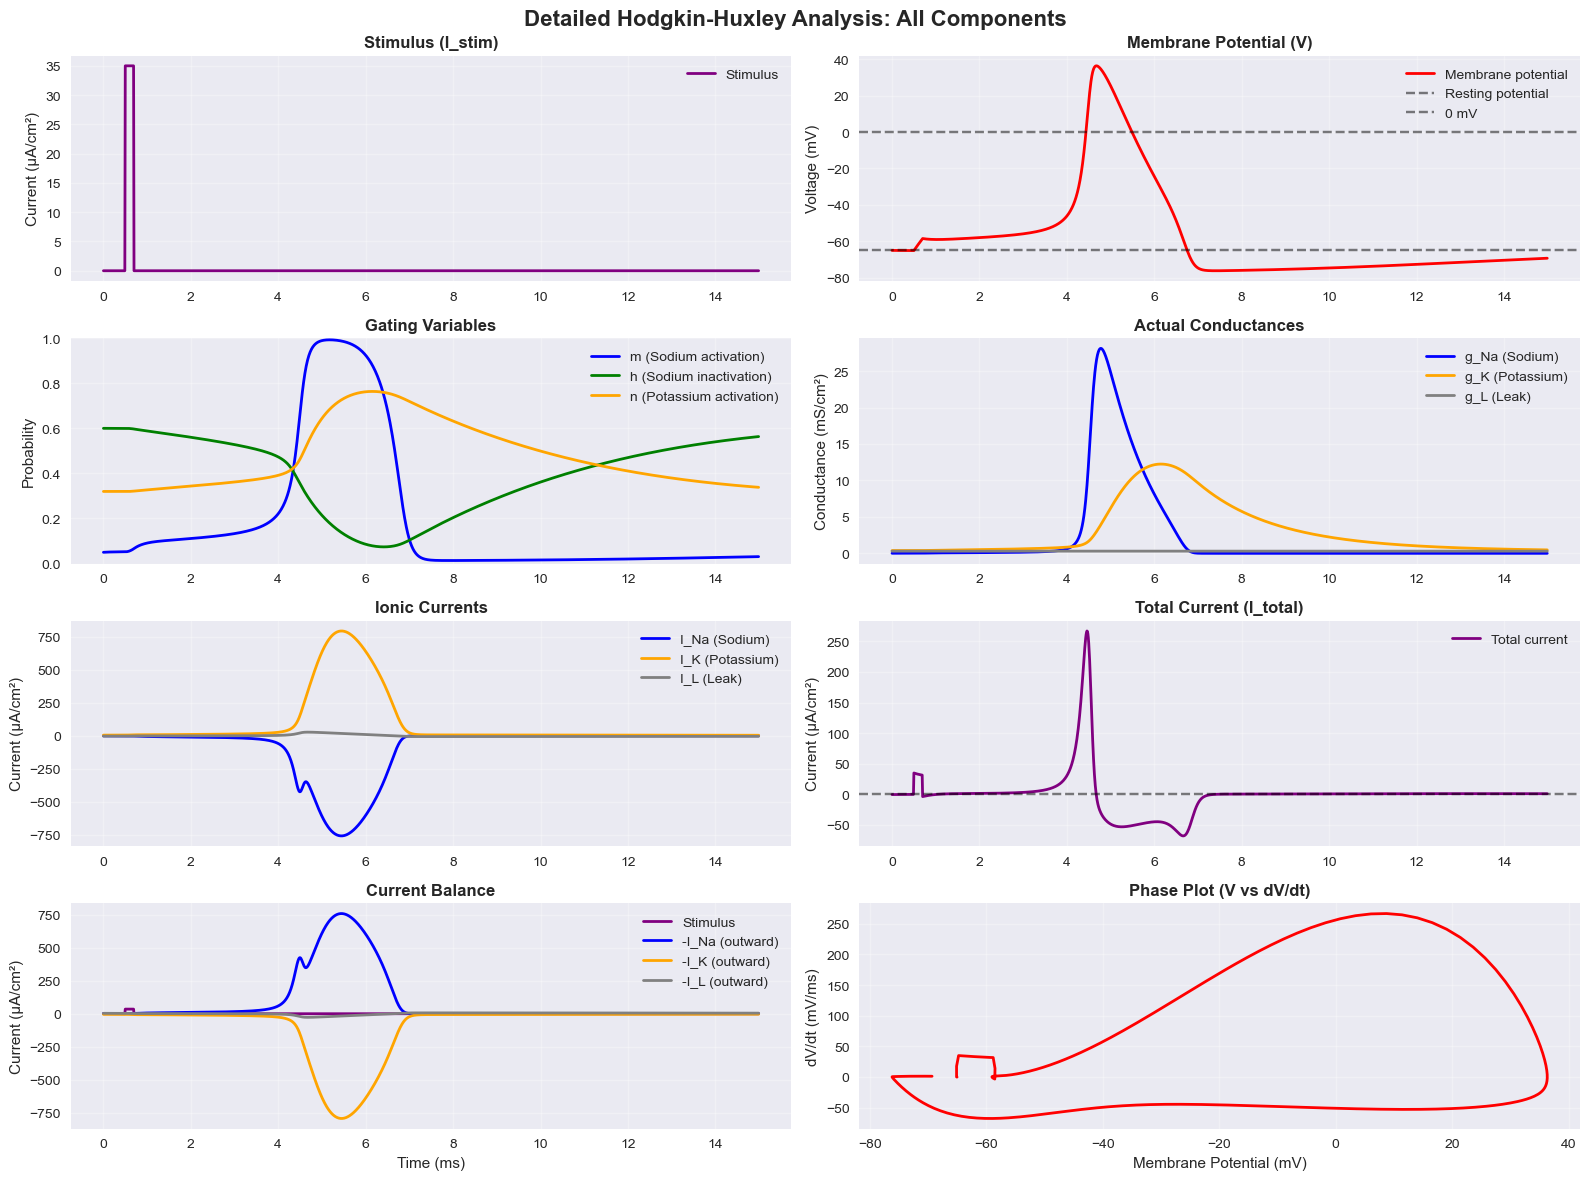

🔬 DETAILED HODGKIN-HUXLEY ANALYSIS
📊 Peak values:
   Peak time: 4.7 ms
   Peak voltage: 36.3 mV
   Peak m: 0.909
   Peak h: 0.295
   Peak n: 0.537

⚡ Current values at peak:
   I_Na: -363.25 μA/cm²
   I_K: 340.54 μA/cm²
   I_L: 27.22 μA/cm²
   I_total: -4.51 μA/cm²

🔧 Conductance values at peak:
   g_Na: 26.60 mS/cm²
   g_K: 3.00 mS/cm²
   g_L: 0.30 mS/cm²

⏱️  Time constants:
   τ_m: 0.29 ms
   τ_n: 1.67 ms


In [7]:
# Detailed analysis of Hodgkin-Huxley components
def plot_detailed_hodgkin_huxley_analysis():
    """
    Plots all components in the Hodgkin-Huxley model to show how the action potential is formed
    """
    # Generate data again to be sure
    t, V, m, h, n = solve_hodgkin_huxley_wikipedia_style(dt=0.01, t_max=15)
    
    # Calculate all components
    C_m = 1.0
    g_Na = 120.0
    g_K = 36.0
    g_L = 0.3
    E_Na = 50.0
    E_K = -77.0
    E_L = -54.4
    
    # Stimulus
    I_stim = np.zeros(len(t))
    I_stim[50:70] = 35.0
    
    # Calculate currents
    I_Na = g_Na * m**3 * h * (V - E_Na)
    I_K = g_K * n**4 * (V - E_K)
    I_L = g_L * (V - E_L)
    I_total = I_stim - I_Na - I_K - I_L
    
    # Calculate conductances
    g_Na_actual = g_Na * m**3 * h
    g_K_actual = g_K * n**4
    g_L_actual = g_L * np.ones_like(t)
    
    # Create subplots
    fig, axes = plt.subplots(4, 2, figsize=(16, 12))
    fig.suptitle('Detailed Hodgkin-Huxley Analysis: All Components', fontsize=16, fontweight='bold')
    
    # Plot 1: Stimulus
    axes[0,0].plot(t, I_stim, 'purple', linewidth=2, label='Stimulus')
    axes[0,0].set_title('Stimulus (I_stim)', fontweight='bold')
    axes[0,0].set_ylabel('Current (μA/cm²)')
    axes[0,0].grid(True, alpha=0.3)
    axes[0,0].legend()
    
    # Plot 2: Membrane potential
    axes[0,1].plot(t, V, 'red', linewidth=2, label='Membrane potential')
    axes[0,1].axhline(y=-65, color='k', linestyle='--', alpha=0.5, label='Resting potential')
    axes[0,1].axhline(y=0, color='k', linestyle='--', alpha=0.5, label='0 mV')
    axes[0,1].set_title('Membrane Potential (V)', fontweight='bold')
    axes[0,1].set_ylabel('Voltage (mV)')
    axes[0,1].grid(True, alpha=0.3)
    axes[0,1].legend()
    
    # Plot 3: Gating variables
    axes[1,0].plot(t, m, 'blue', linewidth=2, label='m (Sodium activation)')
    axes[1,0].plot(t, h, 'green', linewidth=2, label='h (Sodium inactivation)')
    axes[1,0].plot(t, n, 'orange', linewidth=2, label='n (Potassium activation)')
    axes[1,0].set_title('Gating Variables', fontweight='bold')
    axes[1,0].set_ylabel('Probability')
    axes[1,0].set_ylim(0, 1)
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].legend()
    
    # Plot 4: Conductances
    axes[1,1].plot(t, g_Na_actual, 'blue', linewidth=2, label='g_Na (Sodium)')
    axes[1,1].plot(t, g_K_actual, 'orange', linewidth=2, label='g_K (Potassium)')
    axes[1,1].plot(t, g_L_actual, 'gray', linewidth=2, label='g_L (Leak)')
    axes[1,1].set_title('Actual Conductances', fontweight='bold')
    axes[1,1].set_ylabel('Conductance (mS/cm²)')
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].legend()
    
    # Plot 5: Ionic currents
    axes[2,0].plot(t, I_Na, 'blue', linewidth=2, label='I_Na (Sodium)')
    axes[2,0].plot(t, I_K, 'orange', linewidth=2, label='I_K (Potassium)')
    axes[2,0].plot(t, I_L, 'gray', linewidth=2, label='I_L (Leak)')
    axes[2,0].set_title('Ionic Currents', fontweight='bold')
    axes[2,0].set_ylabel('Current (μA/cm²)')
    axes[2,0].grid(True, alpha=0.3)
    axes[2,0].legend()
    
    # Plot 6: Total current
    axes[2,1].plot(t, I_total, 'purple', linewidth=2, label='Total current')
    axes[2,1].axhline(y=0, color='k', linestyle='--', alpha=0.5)
    axes[2,1].set_title('Total Current (I_total)', fontweight='bold')
    axes[2,1].set_ylabel('Current (μA/cm²)')
    axes[2,1].grid(True, alpha=0.3)
    axes[2,1].legend()
    
    # Plot 7: Current comparison
    axes[3,0].plot(t, I_stim, 'purple', linewidth=2, label='Stimulus')
    axes[3,0].plot(t, -I_Na, 'blue', linewidth=2, label='-I_Na (outward)')
    axes[3,0].plot(t, -I_K, 'orange', linewidth=2, label='-I_K (outward)')
    axes[3,0].plot(t, -I_L, 'gray', linewidth=2, label='-I_L (outward)')
    axes[3,0].set_title('Current Balance', fontweight='bold')
    axes[3,0].set_xlabel('Time (ms)')
    axes[3,0].set_ylabel('Current (μA/cm²)')
    axes[3,0].grid(True, alpha=0.3)
    axes[3,0].legend()
    
    # Plot 8: Phase plot (V vs dV/dt)
    dV_dt = np.gradient(V, t)
    axes[3,1].plot(V, dV_dt, 'red', linewidth=2)
    axes[3,1].set_title('Phase Plot (V vs dV/dt)', fontweight='bold')
    axes[3,1].set_xlabel('Membrane Potential (mV)')
    axes[3,1].set_ylabel('dV/dt (mV/ms)')
    axes[3,1].grid(True, alpha=0.3)
    
    # Adjust layout
    plt.tight_layout()
    plt.show()
    
    # Print detailed values
    print("🔬 DETAILED HODGKIN-HUXLEY ANALYSIS")
    print("=" * 50)
    
    # Find peak values
    peak_idx = np.argmax(V)
    peak_time = t[peak_idx]
    peak_voltage = V[peak_idx]
    
    print(f"📊 Peak values:")
    print(f"   Peak time: {peak_time:.1f} ms")
    print(f"   Peak voltage: {peak_voltage:.1f} mV")
    print(f"   Peak m: {m[peak_idx]:.3f}")
    print(f"   Peak h: {h[peak_idx]:.3f}")
    print(f"   Peak n: {n[peak_idx]:.3f}")
    
    print(f"\n⚡ Current values at peak:")
    print(f"   I_Na: {I_Na[peak_idx]:.2f} μA/cm²")
    print(f"   I_K: {I_K[peak_idx]:.2f} μA/cm²")
    print(f"   I_L: {I_L[peak_idx]:.2f} μA/cm²")
    print(f"   I_total: {I_total[peak_idx]:.2f} μA/cm²")
    
    print(f"\n🔧 Conductance values at peak:")
    print(f"   g_Na: {g_Na_actual[peak_idx]:.2f} mS/cm²")
    print(f"   g_K: {g_K_actual[peak_idx]:.2f} mS/cm²")
    print(f"   g_L: {g_L_actual[peak_idx]:.2f} mS/cm²")
    
    # Calculate time constants
    def find_time_constant(t, var, start_idx, end_idx):
        """Find the time constant for a variable"""
        start_val = var[start_idx]
        end_val = var[end_idx]
        target_val = start_val + 0.63 * (end_val - start_val)
        
        for i in range(start_idx, end_idx):
            if var[i] >= target_val:
                return t[i] - t[start_idx]
        return None
    
    # Find time constants for gating variables
    m_tau = find_time_constant(t, m, 50, 100)
    h_tau = find_time_constant(t, h, 50, 200)
    n_tau = find_time_constant(t, n, 50, 300)
    
    print(f"\n⏱️  Time constants:")
    if m_tau: print(f"   τ_m: {m_tau:.2f} ms")
    if h_tau: print(f"   τ_h: {h_tau:.2f} ms")
    if n_tau: print(f"   τ_n: {n_tau:.2f} ms")

# Run the detailed analysis
plot_detailed_hodgkin_huxley_analysis()

#### 🔬 Mathematical Description of the Hodgkin-Huxley Model

*For **those particularly interested**: The complete mathematical formulation*

##### 📐 What is a Differential Equation?

**Simple definition:**
A differential equation describes how a quantity changes over time. It tells us not only what happens, but **how fast** it happens.

**Everyday example:**
- **Temperature**: "The coffee cools down by 2°C per minute"
- **Mathematical**: $\frac{dT}{dt} = -2$ (where T is temperature, t is time)
- **Meaning**: For each minute that passes, the temperature drops by 2 degrees

**In biology:**
- **Population**: "The number of bacteria increases by 10% per hour"
- **Mathematical**: $\frac{dP}{dt} = 0.1P$ (where P is the number of bacteria)
- **Meaning**: The more bacteria, the faster they grow

##### 🔗 Coupling of Differential Equations

**The Hodgkin-Huxley model has 4 coupled differential equations:**

1. **Membrane potential** depends on ionic currents:
   $$\frac{dV}{dt} = f(V, m, h, n)$$

2. **Gating variables** depend on membrane potential:
   $$\frac{dm}{dt} = f(V)$$
   $$\frac{dh}{dt} = f(V)$$
   $$\frac{dn}{dt} = f(V)$$

3. **Ionic currents** depend on both V and gating variables:
   $$I_{Na} = f(V, m, h)$$
   $$I_K = f(V, n)$$

**Why are they coupled?**
- **V** affects **m, h, n** (voltage opens/closes channels)
- **m, h, n** affect **I_Na, I_K** (open channels let ions flow)
- **I_Na, I_K** affect **V** (ionic currents change voltage)
- **The result**: A "feedback loop" that creates the action potential

##### 🧠 Biological Analogy

**Think of it as a "domino effect":**
1. **Stimulus** → Changes membrane potential (V)
2. **V changes** → Opens sodium channels (m increases)
3. **m increases** → More sodium flows in (I_Na increases)
4. **I_Na increases** → V changes even more (depolarization)
5. **V increases** → Opens potassium channels (n increases)
6. **n increases** → Potassium flows out (I_K increases)
7. **I_K increases** → V returns (repolarization)

**Each "domino piece" affects the others** - that's why we need coupled differential equations!

##### 🔢 Numerical Solution

**Problem**: We cannot solve 4 coupled differential equations analytically (with a closed formula)
**Solution**: Euler's method - we "jump" in small time steps

**Euler's method:**
$$V_{i+1} = V_i + \Delta t \cdot \frac{dV}{dt}\Big|_{V_i}$$

**Why does it work?**
- We start with known initial values
- We calculate the rate of change
- We "jump" a small step forward
- We repeat the process

**Example:**
- **Start**: V₀ = -65 mV
- **Calculate**: dV/dt = +50 mV/ms
- **Jump**: V₁ = -65 + 0.01 × 50 = -64.5 mV
- **Repeat**: V₂ = -64.5 + 0.01 × 45 = -64.05 mV
- **And so on...**

##### 🏥 Clinical Relevance

**Why is this important for healthcare professionals?**
- **Medications**: Affect ion channels → change the differential equations
- **Diseases**: Mutations change the parameters → different action potentials
- **Treatment**: We can simulate the effect of treatment beforehand
- **Diagnostics**: Unusual action potentials can indicate disease

**Example - Local Anesthesia:**
- **Lidocaine** blocks sodium channels
- **Effect**: α_m(V) → 0 (channels don't open)
- **Result**: No action potentials → no pain
- **Mathematical**: We set g_Na = 0 in the model

This shows how basic mathematics can help us understand and treat medical problems!


#### More precisely:
The Hodgkin-Huxley model describes the action potential through four differential equations that model the dynamics of ion channels:

**Main equation - Membrane potential:**
$$\frac{dV}{dt} = \frac{1}{C_m}[I_{stim} - I_{Na} - I_K - I_L]$$

**Ionic currents:**
$$I_{Na} = g_{Na} \cdot m^3 \cdot h \cdot (V - E_{Na})$$
$$I_K = g_K \cdot n^4 \cdot (V - E_K)$$
$$I_L = g_L \cdot (V - E_L)$$

**Gating variables (probabilities for open channels):**
$$\frac{dm}{dt} = \alpha_m(V) \cdot (1-m) - \beta_m(V) \cdot m$$
$$\frac{dh}{dt} = \alpha_h(V) \cdot (1-h) - \beta_h(V) \cdot h$$
$$\frac{dn}{dt} = \alpha_n(V) \cdot (1-n) - \beta_n(V) \cdot n$$

**Rate constants (voltage-dependent transition probabilities):**
$$\alpha_m(V) = \frac{0.1(V+40)}{1-e^{-(V+40)/10}}$$
$$\beta_m(V) = 4e^{-(V+65)/18}$$
$$\alpha_h(V) = 0.07e^{-(V+65)/20}$$
$$\beta_h(V) = \frac{1}{1+e^{-(V+35)/10}}$$
$$\alpha_n(V) = \frac{0.01(V+55)}{1-e^{-(V+55)/10}}$$
$$\beta_n(V) = 0.125e^{-(V+65)/80}$$

**Physical parameters:**
- $C_m = 1.0$ μF/cm² (membrane capacitance)
- $g_{Na} = 120.0$ mS/cm² (maximum sodium conductance)
- $g_K = 36.0$ mS/cm² (maximum potassium conductance)
- $g_L = 0.3$ mS/cm² (leak conductance)
- $E_{Na} = 50.0$ mV (sodium reversal potential)
- $E_K = -77.0$ mV (potassium reversal potential)
- $E_L = -54.4$ mV (leak reversal potential)

**Physical interpretation:**
- **$m$**: Probability that the sodium channel is open (activation)
- **$h$**: Probability that the sodium channel is not inactivated
- **$n$**: Probability that the potassium channel is open
- **$m^3h$**: Probability that the sodium channel is fully functional
- **$n^4$**: Probability that the potassium channel is fully functional

**Numerical solution:**
The model is solved by numerically integrating the differential equations (Euler's method):
$$V_{i+1} = V_i + \Delta t \cdot \frac{dV}{dt}\Big|_{V_i}$$
$$m_{i+1} = m_i + \Delta t \cdot \frac{dm}{dt}\Big|_{V_i}$$
$$h_{i+1} = h_i + \Delta t \cdot \frac{dh}{dt}\Big|_{V_i}$$
$$n_{i+1} = n_i + \Delta t \cdot \frac{dn}{dt}\Big|_{V_i}$$

**Clinical relevance:**
- The model predicts the shape and timing of the action potential
- Can simulate the effect of medications that affect ion channels
- Used to understand hereditary cardiac arrhythmias
- Foundation for the development of pacemaker algorithms


-----

### ✅ Check Your Understanding: Biological Neurons

**Q1:** What is the role of the Hodgkin-Huxley model in neuroscience?

<details>
<summary>Click for answer</summary>

**Answer:** The Hodgkin-Huxley model mathematically describes how neurons generate action potentials through the interplay of:
- **Sodium channels (Na⁺):** Rapid opening causes depolarization (rising phase)
- **Potassium channels (K⁺):** Slower opening causes repolarization (falling phase)
- **Leak channels:** Maintain resting potential

This model earned Hodgkin and Huxley the Nobel Prize (1963) and forms the foundation for computational neuroscience.
</details>

**Q2:** Why is the action potential called "all-or-nothing"?

<details>
<summary>Click for answer</summary>

**Answer:** Once the membrane potential crosses the threshold (~-55 mV):
- The action potential fires with **full amplitude** (~+40 mV spike)
- It **cannot be stopped** once initiated
- The amplitude is **independent** of stimulus strength

Stronger stimuli don't create bigger spikes—they create **more frequent** spikes. This is analogous to a binary 0/1 signal, which inspired the step function in early artificial neurons.
</details>

**Q3:** How does the brain encode information if neurons only fire "on" or "off"?

<details>
<summary>Click for answer</summary>

**Answer:** The brain uses several coding strategies:
- **Rate coding:** Information in firing frequency (more pain → more spikes/second)
- **Temporal coding:** Information in spike timing (synchrony, patterns)
- **Population coding:** Information in which neurons fire together

This inspired modern neural networks: individual neurons are simple, but patterns of activation across many neurons encode complex information.
</details>

> 🏥 **Medical Relevance:** Understanding action potentials is essential for:
> - EEG/EMG interpretation (electrical brain/muscle signals)
> - Cardiac arrhythmias (ion channel disorders)
> - Epilepsy (abnormal neuronal firing patterns)
> - Drug targets (many medications affect ion channels)

---

## 2. Artificial Neurons: From the Brain to the Machine

### Perceptron: The Simplest Neural Network

#### 🏛️ Historical Background

The perceptron was invented by **Frank Rosenblatt** in 1957 at Cornell University. This was a revolutionary discovery that inspired an entire generation of AI researchers. Rosenblatt was inspired by how biological neurons function, and tried to create a simple mathematical model of the nerve cell.

**Important milestones:**
- **1957**: Rosenblatt presents the perceptron
- **1958**: First hardware implementation (Mark I Perceptron)
- **1969**: Minsky & Papert show the limitations (XOR problem)
- **1980s**: "Renaissance" with backpropagation
- **2010s**: Modern deep learning builds on perceptron principles

#### 🧠 How the Perceptron Simulates Biological Neurons

An artificial neuron (perceptron) works like this:

1. **Input**: Receives numerical values (x₁, x₂, ..., xₙ)
   - *Corresponds to*: Synaptic signals from other neurons
   - *In medicine*: Symptoms, laboratory values, vital parameters

2. **Weights**: Each input has a weight (w₁, w₂, ..., wₙ)
   - *Corresponds to*: The strength of synaptic connections
   - *In medicine*: How important each symptom/laboratory value is for the diagnosis

3. **Summation**: Calculates weighted sum: z = w₁x₁ + w₂x₂ + ... + wₙxₙ + b  (b is bias)
   - *Corresponds to*: Integration of all incoming signals in the soma
   - *In medicine*: Assessment of all symptoms and findings together

4. **Activation**: Applies an activation function: y = f(z)
   - *Corresponds to*: The action potential that is formed
   - *In medicine*: The decision about diagnosis or treatment

5. **Output**: Sends the result forward
   - *Corresponds to*: The action potential sent to other neurons
   - *In medicine*: Diagnosis, treatment recommendation, or further evaluation

#### 🏥 Medical Analogies

**In a medical context:**
- **Input** = Patient's symptoms and findings
- **Weights** = Your experience with how important each symptom is
- **Summation** = Your mental assessment of all findings
- **Activation** = Your decision about diagnosis
- **Output** = Your recommendation for follow-up and treatment

**For Nurses:**
- **Input** = Vital parameters, patient observations
- **Weights** = Your clinical experience with each parameter
- **Summation** = Your assessment of the patient's condition
- **Activation** = Your decision to notify a physician
- **Output** = Your action or recommendation

**For Psychologists:**
- **Input** = Patient's behavior, statements, test results
- **Weights** = Your theoretical and clinical knowledge
- **Summation** = Your psychological assessment
- **Activation** = Your diagnostic decision
- **Output** = Your treatment plan or recommendation

#### 🔬 Mathematical Formulation

**z = wᵀx + b**

Where:
- **w** = weight vector (synaptic strengths)
- **x** = input vector (incoming signals)
- **b** = bias (threshold for activation)
- **z** = net input (total stimulation)
- **y = f(z)** = output (activation level)

#### 🎯 Practical Examples in Medicine

**Example 1: Heart Attack Diagnosis**
- **Input**: Chest pain (0-10), ECG changes (0-1), troponin values (0-100)
- **Weights**: Chest pain=0.3, ECG=0.5, troponin=0.2
- **Summation**: z = 0.3×8 + 0.5×1 + 0.2×85 = 2.4 + 0.5 + 17 = 19.9
- **Activation**: f(19.9) = 1 (high probability of heart attack)
- **Output**: "Acute myocardial infarction - immediate treatment"

**Example 2: Depression Screening**
- **Input**: Mood (1-10), sleep (1-10), appetite (1-10), energy (1-10)
- **Weights**: All weights = 0.25 (equally important)
- **Summation**: z = 0.25×2 + 0.25×3 + 0.25×4 + 0.25×2 = 2.75
- **Activation**: f(2.75) = 0.8 (high probability of depression)
- **Output**: "Recommend further psychological evaluation"

#### ⚠️ Limitations and Challenges

**The perceptron can only learn linear patterns:**
- Works well for simple medical decisions
- Cannot handle complex, non-linear relationships
- Needs multiple layers (deep learning) for advanced medical problems

**Examples of what the perceptron CANNOT do:**
- Complex image diagnostics (requires CNN)
- Time series analysis of ECG (requires RNN)
- Multilingual text analysis (requires transformer)

#### 🔗 Connection to Modern AI in Medicine

The perceptron is the foundation for:
- **Deep Learning**: Multiple layers of perceptrons
- **CNN**: For image diagnostics
- **RNN**: For time series data (ECG, EEG)
- **Transformer**: For natural language processing

This shows how a simple idea from 1957 has evolved into the advanced AI systems we use in medicine today!


### Visualization of the perceptron

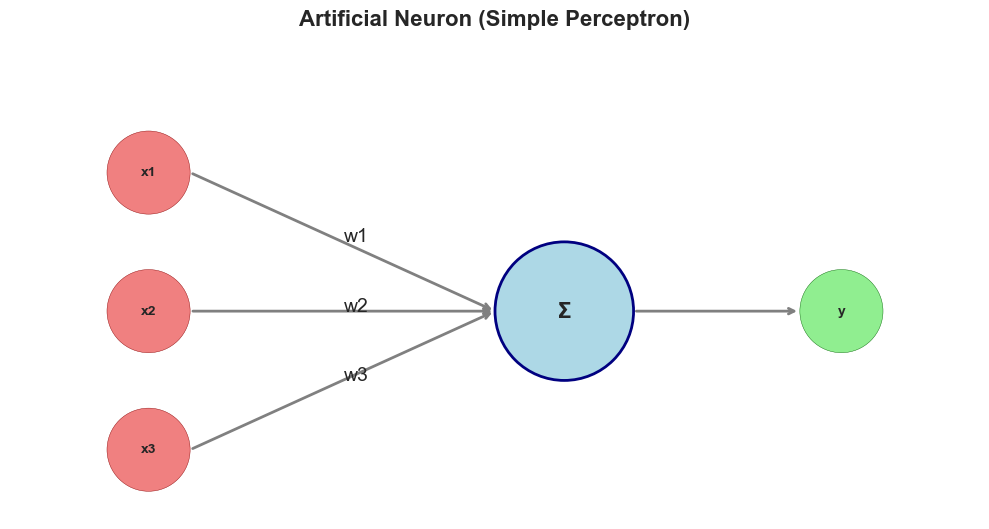

In [8]:
# Visualize the perceptron
def plot_perceptron():
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    
    # Draw input nodes
    for i in range(3):
        circle = Circle((1, 2-i), 0.3, color='lightcoral', ec='darkred')
        ax.add_patch(circle)
        ax.text(1, 2-i, f'x{i+1}', ha='center', va='center', fontweight='bold')
    
    # Draw main neuron
    circle = Circle((4, 1), 0.5, color='lightblue', ec='navy', linewidth=2)
    ax.add_patch(circle)
    ax.text(4, 1, 'Σ', ha='center', va='center', fontsize=16, fontweight='bold')
    
    # Draw output
    circle = Circle((6, 1), 0.3, color='lightgreen', ec='darkgreen')
    ax.add_patch(circle)
    ax.text(6, 1, 'y', ha='center', va='center', fontweight='bold')
    
    # Draw connections
    for i in range(3):
        ax.annotate('', xy=(3.5, 1), xytext=(1.3, 2-i),
                   arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
        # ax.text(2.5, 1.5-i*0.3, f'w{i+1}', ha='center', fontsize=10)
        ax.text(2.5, (2-i + 1)/2, f'w{i+1}', ha='center', fontsize=14)
    
    ax.annotate('', xy=(5.7, 1), xytext=(4.5, 1),
               arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
    
    ax.set_xlim(0, 7)
    ax.set_ylim(-0.5, 3)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Artificial Neuron (Simple Perceptron)', fontsize=16, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

plot_perceptron()


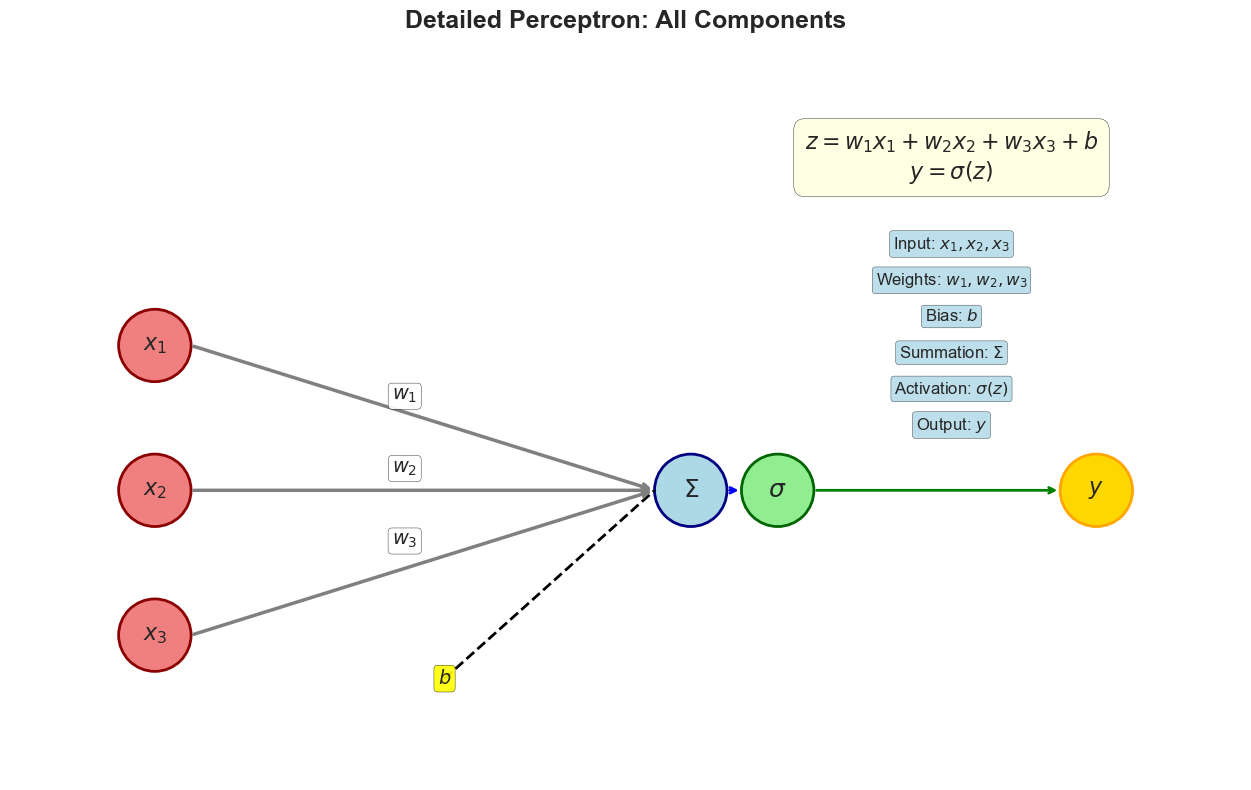

In [9]:
# Improved Perceptron visualization with LaTeX and better layout
def plot_detailed_perceptron():
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    
    # Input nodes with LaTeX symbols
    input_positions = [(1, 2.5), (1, 1.5), (1, 0.5)]
    input_labels = [r'$x_1$', r'$x_2$', r'$x_3$']
    
    for i, (pos, label) in enumerate(zip(input_positions, input_labels)):
        # Draw input node
        circle = Circle(pos, 0.25, color='lightcoral', ec='darkred', linewidth=2)
        ax.add_patch(circle)
        ax.text(pos[0], pos[1], label, ha='center', va='center', fontweight='bold', fontsize=16)
    
    # Main neuron with summation and activation function
    main_pos = (5, 1.5)
    
    # Draw summation part
    circle1 = Circle((main_pos[0]-0.3, main_pos[1]), 0.25, color='lightblue', ec='navy', linewidth=2)
    ax.add_patch(circle1)
    ax.text(main_pos[0]-0.3, main_pos[1], r'$\Sigma$', ha='center', va='center', fontweight='bold', fontsize=18)
    
    # Draw activation function
    circle2 = Circle((main_pos[0]+0.3, main_pos[1]), 0.25, color='lightgreen', ec='darkgreen', linewidth=2)
    ax.add_patch(circle2)
    ax.text(main_pos[0]+0.3, main_pos[1], r'$\sigma$', ha='center', va='center', fontweight='bold', fontsize=18)
    
    # Output node
    output_pos = (7.5, 1.5)
    circle = Circle(output_pos, 0.25, color='gold', ec='orange', linewidth=2)
    ax.add_patch(circle)
    ax.text(output_pos[0], output_pos[1], r'$y$', ha='center', va='center', fontweight='bold', fontsize=16)
    
    # Draw connections with weights
    weight_values = [r'$w_1$', r'$w_2$', r'$w_3$']
    for i, (input_pos, weight) in enumerate(zip(input_positions, weight_values)):
        # Draw arrow from input to summation
        ax.annotate('', xy=(main_pos[0]-0.55, main_pos[1]), xytext=(input_pos[0]+0.25, input_pos[1]),
                   arrowprops=dict(arrowstyle='->', lw=2.5, color='gray'))
        
        # Place weight label in the middle of the arrow
        mid_x = (input_pos[0] + main_pos[0]-0.55) / 2
        mid_y = (input_pos[1] + main_pos[1]) / 2
        ax.text(mid_x, mid_y + 0.15, weight, ha='center', va='center', fontweight='bold', 
                fontsize=14, bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.9))
    
    # Draw bias connection
    bias_pos = (3, 0.2)
    ax.plot([bias_pos[0], main_pos[0]-0.55], [bias_pos[1], main_pos[1]], 'k--', linewidth=2)
    ax.text(bias_pos[0], bias_pos[1], r'$b$', ha='center', va='center', fontweight='bold', 
            fontsize=14, bbox=dict(boxstyle='round,pad=0.2', facecolor='yellow', alpha=0.9))
    
    # Draw connection from summation to activation function
    ax.annotate('', xy=(main_pos[0]+0.05, main_pos[1]), xytext=(main_pos[0]-0.05, main_pos[1]),
               arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
    
    # Draw connection from activation function to output
    ax.annotate('', xy=(output_pos[0]-0.25, output_pos[1]), xytext=(main_pos[0]+0.55, main_pos[1]),
               arrowprops=dict(arrowstyle='->', lw=2, color='green'))
    
    # Add mathematical formula in upper right
    formula_text = r"$z = w_1x_1 + w_2x_2 + w_3x_3 + b$" + "\n" + r"$y = \sigma(z)$"
    ax.text(6.5, 3.8, formula_text, ha='center', va='center', fontsize=16, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.9))
    
    # Add component explanations in upper right (below the formula)
    explanations = [
        r"Input: $x_1, x_2, x_3$",
        r"Weights: $w_1, w_2, w_3$", 
        r"Bias: $b$",
        r"Summation: $\Sigma$",
        r"Activation: $\sigma(z)$",
        r"Output: $y$"
    ]
    
    # Place legend in upper right
    legend_y_start = 3.2
    for i, explanation in enumerate(explanations):
        ax.text(6.5, legend_y_start-i*0.25, explanation, ha='center', va='center', fontsize=12, 
                bbox=dict(boxstyle='round,pad=0.2', facecolor='lightblue', alpha=0.8))
    
    # Set up axes
    ax.set_xlim(0, 8.5)
    ax.set_ylim(-0.5, 4.5)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title('Detailed Perceptron: All Components', fontsize=18, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()

# Run the improved visualization
plot_detailed_perceptron()

-----

## 3. Activation Functions: The Brain's "Switches"

### Why do we need activation functions?

Without activation functions, neural networks would just be linear transformations - no matter how many layers we have, we can always reduce it to a single layer. Activation functions introduce **non-linearity**, which is essential for learning complex patterns.

### Common Activation Functions

| Function | Formula | Use | Advantages | Disadvantages |
|----------|--------|------|----------|---------|
| **Sigmoid** | σ(z) = 1/(1+e⁻ᶻ) | Binary classification | Smooth (many times differentiable), bounded | Vanishing gradient  |
| **Tanh** (Hyperbolic tangent)| tanh(z) | Centered output | Larger gradients | Vanishing gradient |
| **ReLU** (Rectified Linear Unit)| max(0,z) | Deep networks | Simple, fast | "Dying ReLU" |
| **Leaky ReLU** | max(0.01z,z) | Improvement of ReLU | Solves "dying ReLU" | Extra parameter |


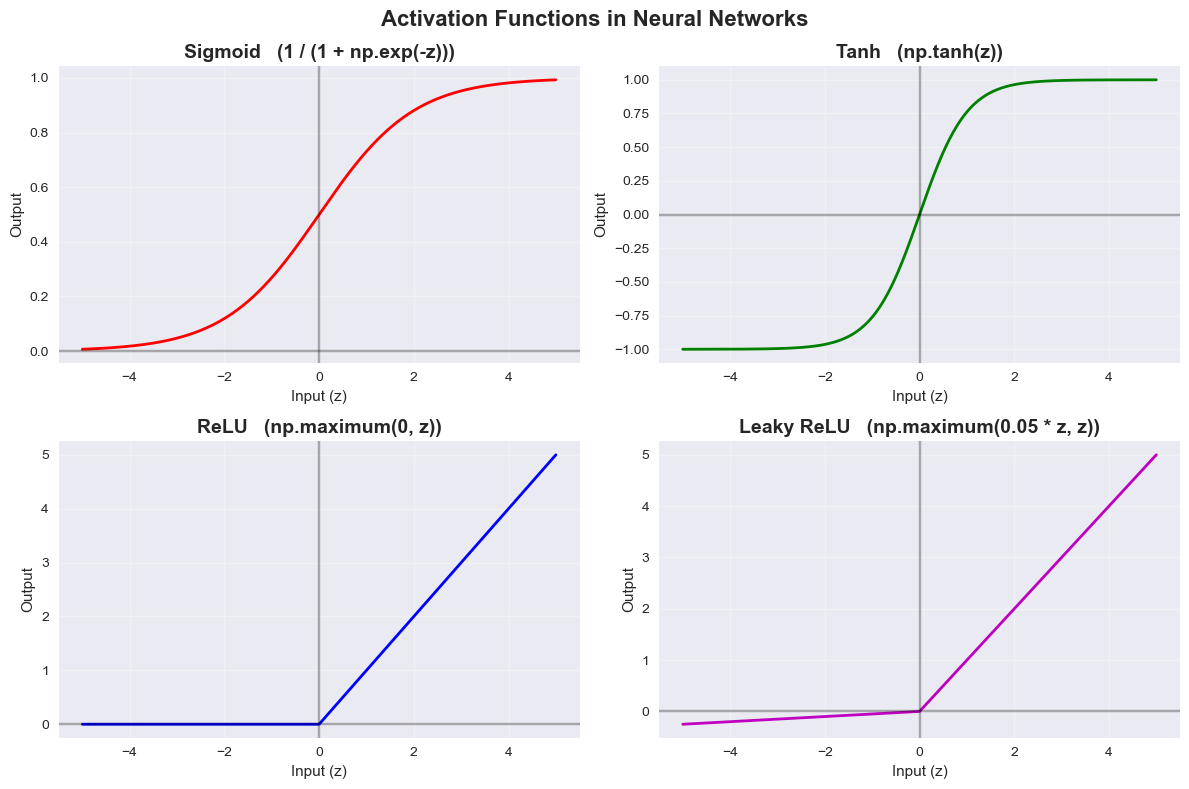

In [10]:
# Visualize activation functions
def plot_activation_functions():
    z = np.linspace(-5, 5, 1000)
    
    # Define functions
    sigmoid = 1 / (1 + np.exp(-z))
    tanh = np.tanh(z)
    relu = np.maximum(0, z)
    leaky_relu = np.maximum(0.05 * z, z)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    
    functions = [
        (sigmoid, 'Sigmoid   (1 / (1 + np.exp(-z)))', 'r'),
        (tanh, 'Tanh   (np.tanh(z))', 'g'),
        (relu, 'ReLU   (np.maximum(0, z))', 'b'),
        (leaky_relu, 'Leaky ReLU   (np.maximum(0.05 * z, z))', 'm')
    ]
    
    for i, (func, name, color) in enumerate(functions):
        axes[i].plot(z, func, color=color, linewidth=2)
        axes[i].set_title(f'{name}', fontsize=14, fontweight='bold')
        axes[i].grid(True, alpha=0.3)
        axes[i].set_xlabel('Input (z)')
        axes[i].set_ylabel('Output')
        axes[i].axhline(y=0, color='k', linestyle='-', alpha=0.3)
        axes[i].axvline(x=0, color='k', linestyle='-', alpha=0.3)
    
    plt.suptitle('Activation Functions in Neural Networks', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_activation_functions()


### Perceptron Computations (PyTorch) 
 - with different combinations of input signal ($\mathbf{x}$) and type of activation function (Sigmoid, ReLU, Tanh) with corresponding output result ($y$)

🧠 SIMPLE PERCEPTRON WITH DIFFERENT ACTIVATION FUNCTIONS
📌 Fixed weights and bias for fair comparison

⚖️  Fixed weights: tensor([ 0.5000, -0.8000,  1.2000])
➕ Fixed bias: tensor([0.3000])

🔍 TEST 1: Mixed
📥 Input: tensor([ 0.5000, -0.3000,  0.8000])
--------------------------------------------------
🧮 Net input (z): 1.7500
🔵 Sigmoid output: 0.8520
🔴 ReLU output:    1.7500
🟢 Tanh output:    0.9414

🔍 TEST 2: All positive
📥 Input: tensor([1., 1., 1.])
--------------------------------------------------
🧮 Net input (z): 1.2000
🔵 Sigmoid output: 0.7685
🔴 ReLU output:    1.2000
🟢 Tanh output:    0.8337

🔍 TEST 3: All negative
📥 Input: tensor([-1., -1., -1.])
--------------------------------------------------
🧮 Net input (z): -0.6000
🔵 Sigmoid output: 0.3543
🔴 ReLU output:    0.0000
🟢 Tanh output:    -0.5370

🔍 TEST 4: All zero
📥 Input: tensor([0., 0., 0.])
--------------------------------------------------
🧮 Net input (z): 0.3000
🔵 Sigmoid output: 0.5744
🔴 ReLU output:    0.3000
🟢 Tanh outpu

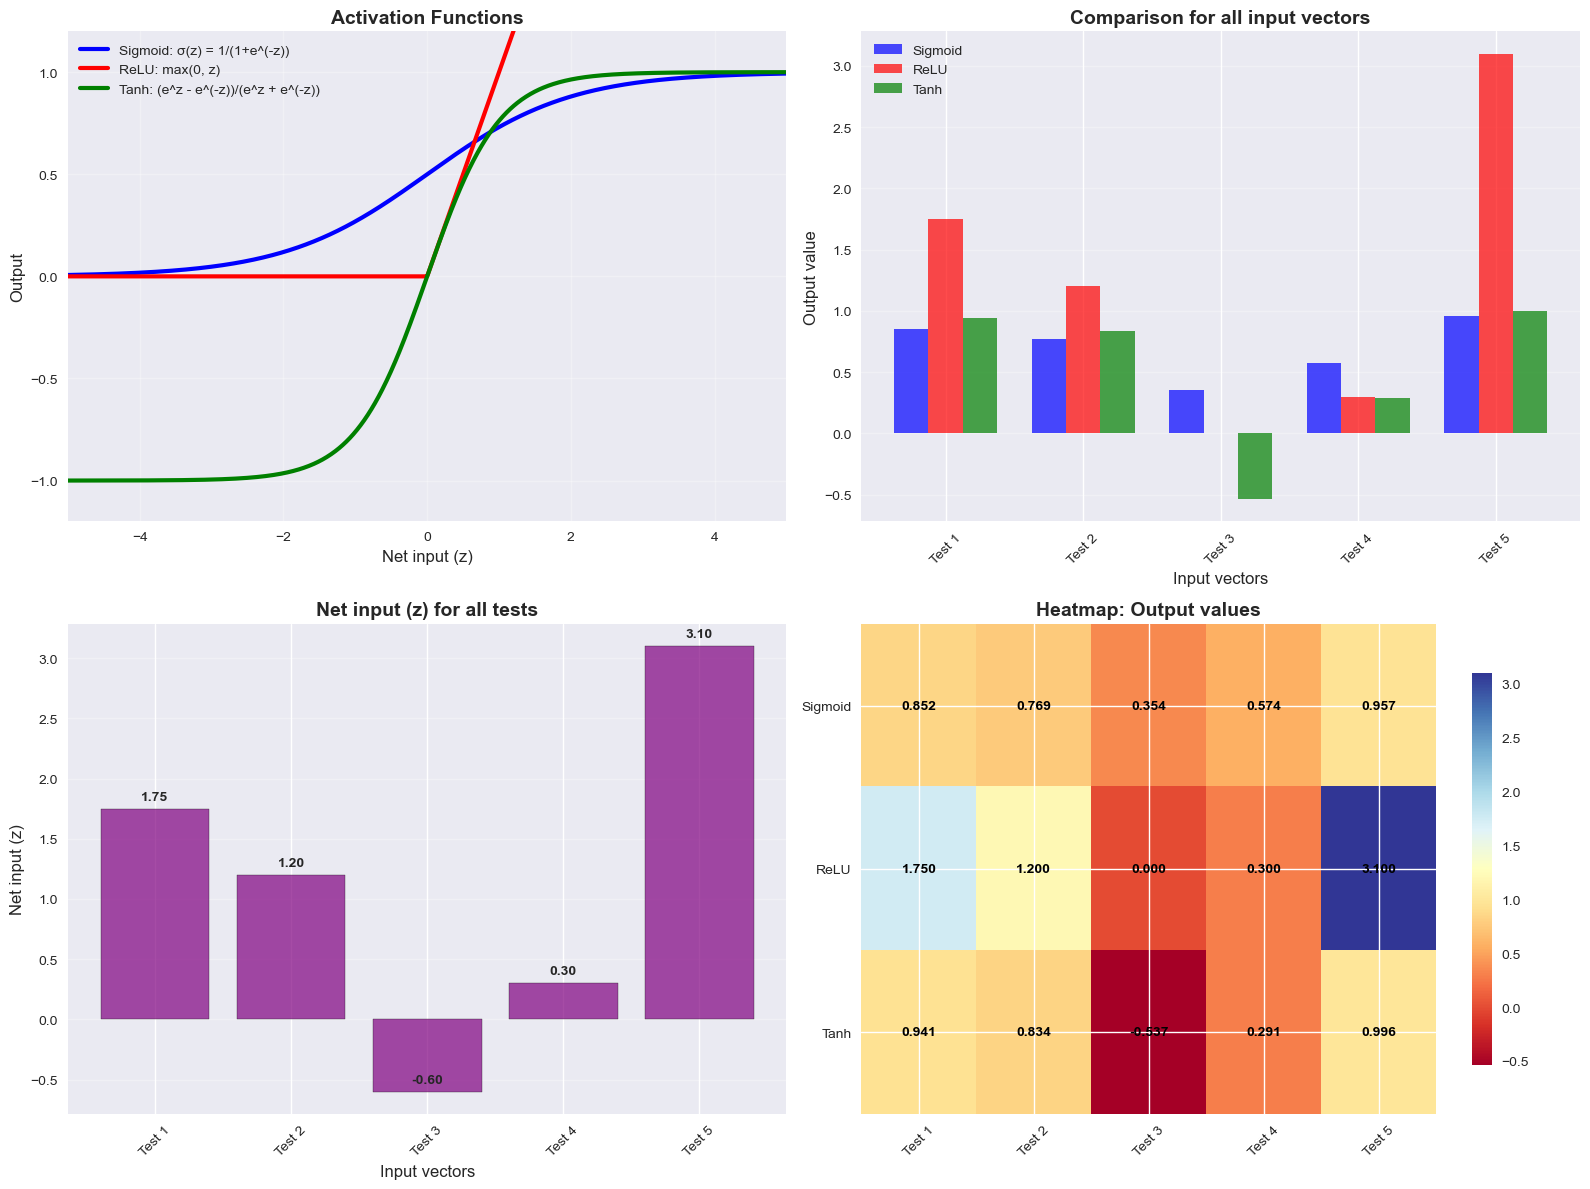


📚 EXPLANATION OF ACTIVATION FUNCTIONS
🔵 SIGMOID:
   • Output: 0 to 1
   • Often used in output layers for classification
   • Smooth curve, differentiable everywhere
   • Can have 'vanishing gradient' problem
   • Observe: All negative z-values give output < 0.5

🔴 ReLU (Rectified Linear Unit):
   • Output: 0 to +∞
   • Most popular in deep networks
   • Simple to compute and differentiate
   • Solves 'vanishing gradient' problem
   • Observe: All negative z-values give output = 0

🟢 TANH (Hyperbolic Tangent):
   • Output: -1 to +1
   • Centered around 0
   • Larger gradients than sigmoid
   • Used in RNN (recurrent networks) and LSTM (long short-term memory networks)
   • Observe: Symmetric about origin

🔍 OBSERVATIONS FROM THE TESTS:
   • Same weights and bias used for fair comparison
   • Different input vectors show different properties
   • ReLU 'cuts off' negative values (output = 0)
   • Sigmoid compresses all values to 0-1 range
   • Tanh preserves both positive and negative v

In [11]:
# =============================================================================
# SIMPLE PERCEPTRON IMPLEMENTATION
# =============================================================================
# A perceptron is the simplest artificial neuron:
#   1. Takes multiple inputs (like dendrites receiving signals)
#   2. Multiplies each by a weight (like synaptic strength)
#   3. Adds them up plus a bias (like membrane potential)
#   4. Applies activation function (like action potential threshold)
#
# Formula: y = activation(w₁x₁ + w₂x₂ + ... + wₙxₙ + b)
#        = activation(w·x + b)
# =============================================================================

class SimplePerceptron:
    """
    A simple perceptron (single artificial neuron) with configurable activation.
    
    Attributes:
        weights: Connection strengths for each input (learned parameters)
        bias: Threshold offset (learned parameter)
        activation: Non-linear function applied to weighted sum
    """
    
    def __init__(self, input_size, activation='sigmoid', weights=None, bias=None):
        """
        Initialize perceptron with given or random weights.
        
        Args:
            input_size: Number of input features
            activation: 'sigmoid', 'relu', or 'tanh'
            weights: Optional fixed weights (for reproducibility demos)
            bias: Optional fixed bias
        """
        # Use fixed weights and bias if provided, otherwise random
        if weights is not None:
            self.weights = weights.clone().detach().requires_grad_(True)
        else:
            self.weights = torch.randn(input_size, requires_grad=True)
            
        if bias is not None:
            self.bias = bias.clone().detach().requires_grad_(True)
        else:
            self.bias = torch.randn(1, requires_grad=True)
            
        self.activation = activation
    
    def forward(self, x):
        """
        Forward pass: compute output from inputs.
        
        Biological analogy:
        - x: incoming signals from other neurons
        - weights: synaptic strengths
        - z: membrane potential (weighted sum)
        - y: firing rate or action potential
        """
        # Calculate net input (z = w^T * x + b)
        # This is the "membrane potential" in biological terms
        z = torch.dot(self.weights, x) + self.bias
        
        # Apply selected activation function
        # This is the "firing decision" - analogous to action potential
        if self.activation == 'sigmoid':
            y = torch.sigmoid(z)      # Output: 0-1 (like firing probability)
        elif self.activation == 'relu':
            y = torch.relu(z)         # Output: 0 or positive (like firing rate)
        elif self.activation == 'tanh':
            y = torch.tanh(z)         # Output: -1 to 1 (like inhibition/excitation)
        else:
            raise ValueError(f"Unknown activation function: {self.activation}")
            
        return y, z  # Return both output and net input
    
    def parameters(self):
        """Return learnable parameters (for gradient-based learning)."""
        return [self.weights, self.bias]

# Set random seed for reproducible results (use global constant)
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print("=" * 70)
print("🧠 SIMPLE PERCEPTRON WITH DIFFERENT ACTIVATION FUNCTIONS")
print("=" * 70)
print("📌 Fixed weights and bias for fair comparison")
print()

# Define fixed weights and bias (same for all activation functions)
fixed_weights = torch.tensor([0.5, -0.8, 1.2], dtype=torch.float32)
fixed_bias = torch.tensor([0.3], dtype=torch.float32)

print(f"⚖️  Fixed weights: {fixed_weights}")
print(f"➕ Fixed bias: {fixed_bias}")
print()

# Define several test input vectors
test_inputs = [
    torch.tensor([0.5, -0.3, 0.8], dtype=torch.float32),  # Mixed
    torch.tensor([1.0, 1.0, 1.0], dtype=torch.float32),   # All positive
    torch.tensor([-1.0, -1.0, -1.0], dtype=torch.float32), # All negative
    torch.tensor([0.0, 0.0, 0.0], dtype=torch.float32),   # All zero
    torch.tensor([2.0, -1.5, 0.5], dtype=torch.float32)   # Large values
]

input_names = ["Mixed", "All positive", "All negative", "All zero", "Large values"]

# Test all input vectors
for i, (x, name) in enumerate(zip(test_inputs, input_names)):
    print(f"🔍 TEST {i+1}: {name}")
    print(f"📥 Input: {x}")
    print("-" * 50)
    
    # Test with Sigmoid activation function
    perceptron_sigmoid = SimplePerceptron(3, activation='sigmoid', 
                                        weights=fixed_weights, bias=fixed_bias)
    output_sigmoid, z_sigmoid = perceptron_sigmoid.forward(x)
    
    # Test with ReLU activation function
    perceptron_relu = SimplePerceptron(3, activation='relu', 
                                     weights=fixed_weights, bias=fixed_bias)
    output_relu, z_relu = perceptron_relu.forward(x)
    
    # Test with Tanh activation function
    perceptron_tanh = SimplePerceptron(3, activation='tanh', 
                                     weights=fixed_weights, bias=fixed_bias)
    output_tanh, z_tanh = perceptron_tanh.forward(x)
    
    # Display results
    print(f"🧮 Net input (z): {z_sigmoid.item():.4f}")
    print(f"🔵 Sigmoid output: {output_sigmoid.item():.4f}")
    print(f"🔴 ReLU output:    {output_relu.item():.4f}")
    print(f"🟢 Tanh output:    {output_tanh.item():.4f}")
    print()

# Visualize activation functions and compare results
def plot_comprehensive_comparison():
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Activation functions
    x_vals = torch.linspace(-5, 5, 1000)
    ax1.plot(x_vals, torch.sigmoid(x_vals), 'b-', linewidth=3, label='Sigmoid: σ(z) = 1/(1+e^(-z))')
    ax1.plot(x_vals, torch.relu(x_vals), 'r-', linewidth=3, label='ReLU: max(0, z)')
    ax1.plot(x_vals, torch.tanh(x_vals), 'g-', linewidth=3, label='Tanh: (e^z - e^(-z))/(e^z + e^(-z))')
    ax1.set_xlabel('Net input (z)', fontsize=12)
    ax1.set_ylabel('Output', fontsize=12)
    ax1.set_title('Activation Functions', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=10)
    ax1.set_xlim(-5, 5)
    ax1.set_ylim(-1.2, 1.2)
    
    # Plot 2: Comparison for all input vectors
    all_outputs_sigmoid = []
    all_outputs_relu = []
    all_outputs_tanh = []
    all_z_values = []
    
    for x in test_inputs:
        # Calculate for all activation functions
        z = torch.dot(fixed_weights, x) + fixed_bias
        sigmoid_out = torch.sigmoid(z)
        relu_out = torch.relu(z)
        tanh_out = torch.tanh(z)
        
        all_outputs_sigmoid.append(sigmoid_out.item())
        all_outputs_relu.append(relu_out.item())
        all_outputs_tanh.append(tanh_out.item())
        all_z_values.append(z.item())
    
    x_pos = np.arange(len(input_names))
    width = 0.25
    
    bars1 = ax2.bar(x_pos - width, all_outputs_sigmoid, width, label='Sigmoid', color='blue', alpha=0.7)
    bars2 = ax2.bar(x_pos, all_outputs_relu, width, label='ReLU', color='red', alpha=0.7)
    bars3 = ax2.bar(x_pos + width, all_outputs_tanh, width, label='Tanh', color='green', alpha=0.7)
    
    ax2.set_xlabel('Input vectors', fontsize=12)
    ax2.set_ylabel('Output value', fontsize=12)
    ax2.set_title('Comparison for all input vectors', fontsize=14, fontweight='bold')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels([f'Test {i+1}' for i in range(len(input_names))], rotation=45)
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Net input (z) for all tests
    ax3.bar(range(len(all_z_values)), all_z_values, color='purple', alpha=0.7, edgecolor='black')
    ax3.set_xlabel('Input vectors', fontsize=12)
    ax3.set_ylabel('Net input (z)', fontsize=12)
    ax3.set_title('Net input (z) for all tests', fontsize=14, fontweight='bold')
    ax3.set_xticks(range(len(input_names)))
    ax3.set_xticklabels([f'Test {i+1}' for i in range(len(input_names))], rotation=45)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # Add values on the bars
    for i, z_val in enumerate(all_z_values):
        ax3.text(i, z_val + 0.05, f'{z_val:.2f}', ha='center', va='bottom', fontweight='bold')
    
    # Plot 4: Heatmap of all results
    results_matrix = np.array([all_outputs_sigmoid, all_outputs_relu, all_outputs_tanh])
    im = ax4.imshow(results_matrix, cmap='RdYlBu', aspect='auto')
    ax4.set_xticks(range(len(input_names)))
    ax4.set_xticklabels([f'Test {i+1}' for i in range(len(input_names))], rotation=45)
    ax4.set_yticks(range(3))
    ax4.set_yticklabels(['Sigmoid', 'ReLU', 'Tanh'])
    ax4.set_title('Heatmap: Output values', fontsize=14, fontweight='bold')
    
    # Add values in heatmap
    for i in range(3):
        for j in range(len(input_names)):
            text = ax4.text(j, i, f'{results_matrix[i, j]:.3f}',
                           ha="center", va="center", color="black", fontweight='bold')
    
    # Add colorbar
    plt.colorbar(im, ax=ax4, shrink=0.8)
    
    plt.tight_layout()
    plt.show()

# Run the comprehensive visualization
plot_comprehensive_comparison()

print("\n" + "="*70)
print("📚 EXPLANATION OF ACTIVATION FUNCTIONS")
print("="*70)
print("🔵 SIGMOID:")
print("   • Output: 0 to 1")
print("   • Often used in output layers for classification")
print("   • Smooth curve, differentiable everywhere")
print("   • Can have 'vanishing gradient' problem")
print("   • Observe: All negative z-values give output < 0.5")
print()
print("🔴 ReLU (Rectified Linear Unit):")
print("   • Output: 0 to +∞")
print("   • Most popular in deep networks")
print("   • Simple to compute and differentiate")
print("   • Solves 'vanishing gradient' problem")
print("   • Observe: All negative z-values give output = 0")
print()
print("🟢 TANH (Hyperbolic Tangent):")
print("   • Output: -1 to +1")
print("   • Centered around 0")
print("   • Larger gradients than sigmoid")
print("   • Used in RNN (recurrent networks) and LSTM (long short-term memory networks)")
print("   • Observe: Symmetric about origin")
print()
print("🔍 OBSERVATIONS FROM THE TESTS:")
print("   • Same weights and bias used for fair comparison")
print("   • Different input vectors show different properties")
print("   • ReLU 'cuts off' negative values (output = 0)")
print("   • Sigmoid compresses all values to 0-1 range")
print("   • Tanh preserves both positive and negative values")

### EXERCISE: Perform various experiments with Perceptron computations, feel free to also use hand calculations

### ✅ Check Your Understanding: Artificial Neurons

**Q1:** What are the three key components of a perceptron, and what biological structures do they correspond to?

<details>
<summary>Click for answer</summary>

**Answer:**

| Perceptron Component | Biological Equivalent | Function |
|---------------------|----------------------|----------|
| **Weights (w)** | Synaptic strength | How much each input influences output |
| **Bias (b)** | Resting potential threshold | Baseline activation level |
| **Activation function** | Action potential mechanism | Determines if/how strongly neuron "fires" |

The formula `y = activation(w·x + b)` mirrors how biological neurons sum inputs and fire when threshold is reached.
</details>

**Q2:** Why do we need activation functions? What happens without them?

<details>
<summary>Click for answer</summary>

**Answer:** Without activation functions, neural networks can only learn **linear relationships**:
- Stacking linear layers: `f(g(x)) = A₂(A₁x) = (A₂A₁)x = Ax`
- This is still just a linear transformation!

Activation functions introduce **non-linearity**, allowing networks to learn:
- Curved decision boundaries
- Complex patterns (like recognizing faces)
- Any continuous function (universal approximation theorem)

Medical example: Distinguishing benign vs malignant tumors often requires non-linear boundaries in feature space.
</details>

**Q3:** When would you choose ReLU vs sigmoid activation?

<details>
<summary>Click for answer</summary>

**Answer:**

| Activation | Use When | Advantages | Disadvantages |
|------------|----------|------------|---------------|
| **Sigmoid** | Output layer for binary classification | Outputs probability (0-1) | Vanishing gradients, slow |
| **ReLU** | Hidden layers in deep networks | Fast, no vanishing gradient | "Dead neurons" (output stuck at 0) |
| **Softmax** | Multi-class output | Probabilities sum to 1 | N/A (output layer only) |

Modern deep learning mostly uses ReLU variants (LeakyReLU, GELU) in hidden layers.
</details>

> 💡 **Key Insight:** The perceptron was invented in 1958 by Frank Rosenblatt. Its limitations (can't learn XOR) led to the "AI winter," but the multi-layer perceptron (MLP) solved this and sparked the neural network revolution.

---

----- 

## 4. Neural Networks in Medicine and Healthcare: Practical Applications


#### 🧠 Neurology and Psychiatry
- **EEG analysis**: Detection of epilepsy and sleep disorders
- **fMRI interpretation**: Mapping of brain activity
- **Dementia diagnostics**: Early detection of Alzheimer's disease

#### 🫀 Cardiology
- **ECG analysis**: Detection of arrhythmias and myocardial infarction
- **Echocardiography**: Automatic measurement of heart function
- **Risk assessment**: Prediction of cardiovascular disease

#### 🦴 Radiology
- **X-ray interpretation**: Detection of fractures and pathologies
- **CT scanning**: Automatic segmentation of organs
- **MRI analysis**: Detection of tumors and injuries

#### 👁️ Ophthalmology
- **Retinal scanning**: Detection of diabetic retinopathy
- **Glaucoma screening**: Early detection of eye diseases
- **Macular degeneration**: Monitoring of vision deterioration


#### 🏥 Care and Nursing
- **Fall detection**: Automatic alerting for falls in elderly
- **Activity monitoring**: Tracking of daily activities and routines
- **Medication monitoring**: Reminders and dosing
- **Sleep analysis**: Monitoring of sleep quality and patterns
- **Nutritional assessment**: Analysis of diet and nutritional needs
- **Cognitive assessment**: Early detection of cognitive decline
- **Social interaction**: Chatbots for mental support and conversation
- **Rehabilitation**: Personalized exercise programs

**💡 Practical case study:**  
For a comprehensive example of ECG arrhythmia classification with CNN, see notebook `B4-ECG-arrythmia-CNN.ipynb`.



-----

## 5. Neural Network Comparison: Human vs Machine

**🔮 Remember these are time-dependent assessments and conclusions** - AI is now developing faster than humans ...

### Advantages and Disadvantages

| Aspect | Human | Machine |
|--------|----------|--------|
| **Learning speed** | Slow (years) | Fast (hours/days) |
| **Data volume** | Limited | Unlimited |
| **Generalization** | Excellent | Good with enough data |
| **Explanation** | Intuitive | Difficult |
| **Creativity** | High | Limited |
| **Energy consumption** | Low (20W) | High (kW) |
| **Robustness** | High | Variable |

### Why Combine Both?

In medicine and healthcare, it is often best to combine human expertise with machine learning:

- **Human intuition** + **Machine speed**
- **Clinical experience** + **Objective analysis**
- **Ethical assessment** + **Quantitative prediction**


## 🔬 In-Depth Comments on Human vs Machine

### **Learning Speed - The Great Paradox**

**Human (years):**
- A medical student spends 6+ years on basic training
- Specialization takes another 5-10 years
- But: Learns from few examples ("few-shot learning")
- Example: A child sees 1-2 elephants and recognizes all elephants

**Machine (hours/days):**
- Can be trained on thousands of X-ray images in hours
- But: Often needs millions of examples for the same task
- Example: Image recognition needed 1.2 million images (ImageNet)

**Clinical implication:**
- AI can quickly learn repetitive patterns (ECG interpretation)
- Humans are better at rare/new conditions
- **Conclusion:** AI for screening, humans for complex diagnoses (*until broad evidence shows AI is also better here*)

---

### **Data Volume - Quality vs Quantity**

**Human (extensive experience, contextual learning):**
- A mammography radiologist sees ~2 million images in their career
- Learns from images, clinical context, follow-up, and professional literature
- Selective memory - especially remembers the unusual and important
- Few-shot learning: Can learn from few examples of rare conditions

**Machine (massive data processing, but limited context):**
- Can be trained on millions of images (but medical datasets are often smaller)
- Modern AI (2024+): CAN learn from both images and medical literature
- Needs labeled data (expensive expert annotation: $50-200/image)
- Challenge: Rare diseases have too few examples globally
- Advantage: Perfect consistency and can "remember" all patterns without fatigue

**Practical example:**
```
Mammography screening:
- Human (double reading): 75-85% sensitivity
- AI standalone: 85-90% sensitivity
- Combined (AI + radiologist): 90-95% sensitivity
- Swedish study, 105,000 women screened, showed 29% increase in detection with AI (The Lancet Digital Health, 2025)
```

---

### **Generalization - Transfer Learning**

**Human (excellent - "zero-shot" (first case) learning):**
- Can apply knowledge to new situations intuitively
- "My experience from cardiology helps me in intensive care medicine"
- Can reason analogically: "This resembles X, so I'll try Y"
- Understands context and nuance
- **Zero-shot learning:** Can learn from first case of completely new disease
- Example: An intensive care physician can treat a new infection based on experience with similar infections

**Machine - Varies with AI generation:**

#### **Traditional AI (pre-2023):**
- **"Catastrophic forgetting":** Forgets old when learning new
  - Problem: Train on Task A → good, train on Task B → good, test Task A → poor ❌
- Needs re-training from scratch for new situations
- Handles "out-of-distribution" data poorly
  - Example: AI trained on Hospital A failed on data from Hospital B
- Limited transfer of knowledge between tasks

#### **Modern Foundation Models (2023+):**
- **Dramatically improved generalization:**
  - GPT-4, CLIP, Med-PaLM: Can adapt to new tasks quickly
    - **Zero-shot:** Can handle some new tasks without examples
- **Transfer learning:** Works well across medical domains
    - Example: Model trained on X-ray can be adapted to CT with minimal data
- **Continual learning(*):** New techniques reduce catastrophic forgetting (= methods that allow AI systems to update with new knowledge without losing previous knowledge, i.e., reduces "forgetting"/catastrophic forgetting)
  - Elastic Weight Consolidation, Progressive Neural Networks, ...
- **But:** Still not as flexible as humans in completely new situations
  ***) methods for continual learning**:
- Elastic Weight Consolidation (EWC) is a type of regularization: Small "brakes" that prevent the model from changing too much when learning new things
  - Progressive Neural Networks (PNN): New task gets a new "column" of layers; previous columns are frozen and connected via lateral connections for knowledge transfer - avoids forgetting but increases model size per task
- Replay (memory): Model regularly practices on a small selection of old examples, like repetition of patient cases
- Generative replay: Model creates "synthetic" old examples itself to maintain knowledge
- Small adapters (PEFT): Small "add-ons" per task that are fine-tuned, while the main model remains stable
- Meta/online learning: Learn to learn quickly, and adjust continuously in operation
- Retrieval/test-time adaptation: Look up updated knowledge (RAG) and adjust predictions when data changes
- Foundation models (2024–2025): Ongoing instruction fine-tuning, modular adapters that can be combined, and training on stream of data (often distributed/federated) without collecting everything centrally

**Summary - Generalization Ability in 2024:**

| Aspect | Human | Traditional AI | Modern Foundation Models |
|--------|----------|-----------------|---------------------------|
| **Zero-shot** | Excellent | Poor | Moderate to good |
| **Few-shot** (1-10 ex) | Excellent | Poor | Good |
| **Many-shot** (1000+ ex) | Good | Excellent | Excellent |
| **Analogical reasoning** | Excellent | Poor | Moderate (improving) |
| **Context understanding** | Excellent | Poor | Good (GPT-4) |
| **Completely new situations** | Excellent | Very poor | Moderate |
| **Learning from literature** | Yes | No | Yes (multimodal models) |

**Trend:** The gap between humans and AI is shrinking rapidly, but humans remain superior in completely new, unknown situations with minimal data.


**Summary - Generalization Ability in 2025:**

| Aspect | Human | Traditional AI | Modern Foundation Models (GPT-5 etc.) |
|--------|----------|-----------------|-------------------------------------------|
| **Zero-shot** | Excellent | Poor | Good to very good |
| **Few-shot** (1–10 ex) | Excellent | Poor | Very good |
| **Many-shot** (1000+ ex) | Good | Excellent | Excellent |
| **Analogical reasoning** | Excellent | Poor | Moderate to good (better in-context analogy) |
| **Context understanding** | Excellent | Poor | Very good (with tools/RAG) |
| **Completely new situations** | Excellent | Very poor | Moderate (good in limited domains) |
| **Learning from literature** | Yes | No | Yes, with real-time RAG and citations |

**Trend 2025:** The gap has shrunk further; parity in many routine tasks. Humans are still best in radically new situations, ethics, and holistic clinical assessment.

---

### **Explanation (XAI) – The "Black Box" Problem**

**Human (intuitive):**
- "I think it's pneumonia because..."
- Can explain reasoning and context
- Adjusts based on feedback
- Can express uncertainty and justifications

**Machine (better, but still limitations):**
- Probabilities are more often **calibrated** and accompanied by **uncertainty measures** (confidence, selective prediction/abstain = model only gives answer when sufficiently confident, and "abstains" otherwise)
- Explanation methods go beyond pure saliency maps (= relevance maps / influence maps / attention maps):
    - Image-level: Grad-CAM/Grad-CAM++, Integrated Gradients, occlusion/RISE, SmoothGrad
      - Concept-level: TCAV (Testing with Concept Activation Vectors) - an XAI method that measures how much a human-defined concept affects model's prediction; concept bottleneck models provide transparent "intermediate states" (clinical findings)
    - Counterfactual: "What would need to change to change the conclusion?"
- Important limitation: Many explanations are **post-hoc** and not always fully **faithful** (accurate representation of model's decision basis); saliency requires "sanity checks"
- Better operational safety in clinic: OOD detection (= out-of-distribution detection), shift monitoring (= ongoing measurement to detect distribution shift between training and production, so system can alert, stop or update the model), **bias audits***, logging and traceability
***) bias-audit**:
- **Definition**: Systematic review and testing to detect, measure and reduce biases in data, model and outcomes across groups
  - **Purpose**: Ensure fairness and patient safety; fulfill requirements in regulations (EU AI Act, MDR/IVDR, GDPR).
- **What is checked**: Data distribution, representation, performance per subgroup (sensitivity, specificity, PPV/NPV, calibration), fairness metrics (e.g., equalized odds, demographic parity)
  - **Methods**: Subgroup analysis, calibration per group, counterfactual tests, error analysis, bias checklist (e.g., WHO, HLEG, FAIR); shift monitoring (= ongoing measurement to detect distribution shift between training and production, so system can alert, stop or update the model)
  - **Result**: Audit report with findings, risks, measures and follow-up plan
- **Measures**: Data quality/recalibration, rebalancing/reweighting, adjusted thresholds per subgroup, retraining, selective prediction/abstain, strengthened human oversight

**Legal/ethical (EU, 2025):**

  GDPR art. 22: Applies to automated decisions with legal/significant effect.
– Not explicit "right to explanation", but right to meaningful info (art. 13–15),

EU AI Act (adopted 2024; rolling out 2025–2026):
– Medical AI systems are "high-risk" (together with MDR/IVDR).
– Requirements: risk management, data/bias control, logging/traceability,
    post-market surveillance.
  – "Explainability" should be proportional to risk and context – not a requirement for full
  transparency in weights/code.

**Practical example – beyond saliency:**
  A clinically robust explanation should combine:
 1) Heat/saliency maps (Grad-CAM) + sanity checks
 2) Counterfactual explanation (which region/feature changes the outcome?)
 3) Concept-based signals (e.g., "consolidation", "pleural effusion")
 4) Uncertainty/calibration + option for "abstain"


**Rule of thumb in 2025:**
- Use explanations that are clinically relevant, tested for faithfulness, and combined with uncertainty and operational monitoring.
   - HDIR: Artificial Intelligence [[link](https://www.helsedirektoratet.no/digitalisering-og-e-helse/kunstig-intelligens)]
   - HDIR: Report on Quality Assurance: Use of Artificial Intelligence in Health and Care Services [[link](https://www.helsedirektoratet.no/rapporter/rapport-om-kvalitetssikring-bruk-av-kunstig-intelligens-i-helse-og-omsorgstjenesten)]
     - White Paper 21 (2024–2025) Health for All - Fair Prioritization in Our Common Healthcare [[link](https://www.regjeringen.no/no/aktuelt/helse-for-alle/id3096827)]



---

### **Creativity – The Human Advantage**

**Human (still strongest):**
  - Thinks "outside the box", tolerates ambiguity and can shift perspective
- Serendipity (= making a valuable, unexpected discovery by happy chance – often while looking for something else), and courage to break dogmas (clinical experience, intuition)
- Combines knowledge across domains and assesses ethics, risk and consequences

**Machine (increasing contribution):**
- Generative models (GPT-5, multimodal diffusion/transformer models) can propose hypotheses, designs and experiments; better "tool use" (literature search, code, simulation)
- Shows improved composition, "in-context" analogy, and can explore large solution spaces (molecules, protein compositions, imaging patterns)

**Important limitations (2025):**
- Lack of robust causal understanding (= ability to distinguish cause from correlation and predict what happens with an intervention or counterfactual change, e.g., "antibiotics reduce infection" - not just "antibiotics correlate with improvement") and "grounding" in the world = that the model's concepts and decisions are anchored in real observations, senses/curves/images and physiological mechanisms, not just pattern recognition in text/data); explanations are often post-hoc
- Creativity is often recombination within training bias; genuine breakthrough extrapolation is unstable
- Hallucinations, "reward hacking" (= when a model exploits weaknesses in the objective function/metric to get high "reward" without solving the actual task, e.g., optimizes "low mortality" by recommending fewer high-risk patients for treatment/admission), and metric sensitivity (= performance varies greatly with choice of metric, e.g., AUC vs. sensitivity, thresholds and datasets; one metric can look "good" while clinical quality is poor) require human quality assurance where experts must assess clinical relevance, adjust thresholds, look at calibration and subgroups, and catch undesirable trade-offs (e.g., high AUC but low sensitivity for rare, severe cases → must be adjusted by clinician)

**Medical innovation – illustrations:**
- New antibiotic candidates and molecule proposals via deep learning; the AlphaFold family and structure-based design have accelerated hypothesis development, but clinical validation is crucial
- Automated literature synthesis and study design (AI proposes inclusion criteria/endpoints; human assesses clinical relevance and ethics)
- Radiology/pathology: AI proposes findings and differential diagnoses; expert prioritizes, integrates context and decides

**Historical case (H. pylori):**
- The discovery (identifying the bacterium H. pylori as the cause of gastritis/peptic ulcer) required challenging dogmas, causal thinking and ethically/clinically considered self-experimentation. <br>Today's AI could likely have generated the hypothesis faster (via literature and data mining), but not replaced clinical judgment and validation*

      - Before: The dogma was that peptic ulcers were caused by stress/acid; bacteria "couldn't live" in the stomach 
        - Finding: Warren and Marshall (early 1980s) saw spiral-shaped bacteria in biopsies; identified Helicobacter pylori and urease activity  
    - Method breakthrough: They optimized culturing (microaerophilic conditions, longer incubation) after several "failed" cultures – challenged laboratory dogmas  
        - Ethics and clinic: Such self-experiments would today require approval; later controlled studies showed that eradication cures and prevents ulcers.  
        - Consequence: Changed standard treatment from long-term acid suppression/surgery to short antibiotic course; Nobel Prize in Medicine (2005)

**Outlook (near future):**
  - More causal/neuro-symbolic AI (= combines neural networks and learning from data with symbolic rules/knowledge graphs/logic (explicit domain knowledge) for better explainability, generalization and compliance with clinical rules), better OOD robustness and "selective prediction/abstain" will increase utility in research and clinic
  - "AI suggests – human decides" remains best practice; hybrids likely provide highest innovation rate and safety


---

### **Energy Consumption - Sustainability Perspective**

**Human (20 W):**
- The brain is extremely energy efficient
- Equivalent to an LED light bulb
- Can function for days on limited nutrition
- Natural cooling system (sweating)

**Machine (kW – MW):**

Energy consumption examples (2025):
- "GPT-4-class" training: several GWh (estimate; depends on cluster, PUE, precision)
- DGX/HGX node (8×H100): ~6–8 kW; 64–256 GPU cluster: ~0.3–1.5 MW; hyperscale pod (= a very large, tightly coupled AI cluster, hundreds–tens of thousands of GPU/TPU with high-speed network (NVLink/InfiniBand) and shared high-bandwidth storage, dimensioned in MW, for training/serving foundation models): several MW
- On-device inference (Apple Silicon M2/M3, 4–8B quantized): ~10–25 W system load
  - Karpathy "nanochat"/small LLM locally: sub-10 W (laptop/desktop), real-time
- Mobile/ANE inference (iPhone/Android, small/quantized models): ~1–5 W
- Climate footprint: strongly dependent on power mix, PUE and heat recovery


***) PUE**
- Power Usage Effectiveness (measure of energy efficiency in data centers, number between 0 and 1). 
  PUE = total power to data center / power to IT equipment, the closer to 1.0 the better (ideally 1.0).

**Future solutions:**
- Neuromorphic chips and Spiking Neural Networks (event-driven, very low Watts)
- **Edge AI** - local inference on ANE (= Apple Neural Engine – Apple's dedicated AI accelerator in iPhone/iPad/Mac) / NNAPI (= Android Neural Networks API – Android interface for on-device ML using CPU/GPU/NPU/DSP) / NPU = Neural Processing Unit – dedicated processor/accelerator for neural networks); less data center use)
- Sparsity / **MoE** (= Mixture of Experts – a model architecture where many "expert" sub-models exist, and a gate/routing mechanism activates only a few experts per input), **quantization** (INT8/INT4) (= downgrades numerical precision from floating point, e.g., FP32/FP16 to integers with 8/4 bits for weights/activations - provides significant reduction in memory and bandwidth plus higher speed, with small but often acceptable accuracy reduction and is mostly used for inference), FP8 (= 8-bit floating point formats supported by newer GPUs - preserves more dynamics than INT8, and is used in mixed-precision training/inference, often with BF16/FP16, and requires scaling/calibration for stability)
  - **Distillation*** and small specialist models; adaptive "selective prediction/abstain"
- Infrastructure: renewable power, low PUE, heat recovery and energy-conscious job scheduling

***) Distillation**
- Knowledge distillation: Transfer of "knowledge" from a large teacher model to a smaller student model
- Method: The student is trained on the teacher's "soft" probabilities/logits (often with temperature), possibly also intermediate representations
            - Logits: The teacher's raw output values before softmax (unnormalized class scores)
      - "Soft" probabilities: Softmax on logits with temperature T>1 which makes the distribution flatter (reveals how similar classes are); higher T → softer distribution
- Intermediate representations: Activations/feature maps from the teacher's hidden layers that the student tries to mimic for better general performance.
- Purpose: Compress the model for faster and more energy-efficient execution (e.g., on mobile/edge) with minimal loss in accuracy




### **Robustness – Resistance to Errors**

**Human (high):**
- Functions with incomplete information and noise; can ask for more data/examinations
- Self-correcting ("this doesn't look like the patient"); uses context and experience
- Limitations: fatigue, stress and cognitive biases
**Machine (better, but vulnerable):**
- Vulnerable to small perturbations (adversarial), spurious correlations and "shortcut learning"
- Performance drops with distribution shift (different population, scanner, protocol, prevalence)
  - Sensitive to noise/compression (e.g., ECG artifacts) and data contamination/"leakage"
- 2025: Foundation models more robust (pre-training, data diversity), but still need for monitoring and human oversight

**Adversarial examples (clinically relevant):**

- Subtle image changes → misdiagnosis (X-ray/CT/MRI)
- ECG: Baseline drift/noise → misjudgment of arrhythmia
- Compression/scanner artifacts → model learns equipment, not disease


**Distribution shift (types and causes):**

- Covariate shift: new patient groups / new equipment / new protocols
- Label/prevalence shift: changed disease incidence
- Concept drift: clinical practice or definitions change over time
  - "Site shift": move from hospital A → B (different environment)


**Solutions for robustness:**
- Data/architecture:
  - Varied pre-training, domain generalization like **augmentation** (= creating variations of training data, e.g., rotation, cropping, noise, color change for better robustness/generalization), Mixup (= mixes two images and labels linearly, i.e., x' = λx1+(1−λ)x2; y' similarly, to reduce overfitting) / AugMix (= combines multiple random augmentations and a consistency cost for robustness against noise/corrupt data), ensembling (= combines predictions from multiple models, or seeds/architectures, for more stable and accurate performance)
  - **Adversarial training** (= train the model on deliberately "perturbed" examples as small, targeted perturbations in addition to normal data, so it better tolerates noise/attacks, compression and small artifacts) and **"shortcut" control** (= measures to prevent the model from learning shortcuts/false correlations such as hospital watermarks, laterality markers, tubes/wires, scanner type ("spurious features") instead of disease signs)
- Uncertainty and decision:
  - Calibration (temperature scaling) (= post-adjustment of model probabilities by scaling logits with a single temperature T on validation data, so p-values better match actual frequency where T>1 makes them "flatter"), selective prediction/abstain (= model only gives answer when sufficiently confident; otherwise "abstains" and routes to human - provides higher precision on cases the model actually answers, i.e., trades coverage for quality)
    - OOD detection and shift monitoring (drift dashboards, alert thresholds)
- Adaptation in operation:
    - Domain adaptation at new locations/protocols
- Governance and security:
  - Continuous validation on local data; "shadow mode" before activation (= model runs in background parallel to current practice, without affecting decisions)
  - Bias audits per subgroup (= systematic measurement of model performance separately for different groups, e.g., gender, age, skin color, hospital to detect biases); worst-group-accuracy as key metrics (= key metric where you look at the accuracy of the worst-performing group; the goal is to lift "worst group" to ensure fairness)
    - Logging/traceability, incident handling, post-market surveillance (EU AI Act/MDR/IVDR)

        - **Post-market surveillance (PMS)**: Systematic follow-up of performance, safety and risk after a product/AI system is deployed (real data in clinic), with ongoing improvement and documentation.

        - MDR/IVDR (Medical Device Regulation / In Vitro Diagnostic Medical Devices Regulation):
        - PMS plan, PMCF/PMPF (PM clinical follow-up/PM performance follow-up), vigilance (incidents/deviations), CAPA (= Corrective and Preventive Actions – internal quality processes to correct deviations (corrective) and prevent recurrence/new occurrences (preventive), incl. root cause analysis under MDR/IVDR-QMS) / FSCAs (= Field Safety Corrective Actions – measures in the field to reduce risk, e.g., recall, software update, instructions for use change and communicated via Field Safety Notice (FSN) and reported to authorities (vigilance))
        - Reports: PSUR (Periodic Safety Update Report) and trend reporting to authorities
        - Part of manufacturer's quality management system (QMS)

- EU AI Act (high-risk AI):
        - Post-market monitoring plan: logging/traceability, incident reporting, measures for deviations
        - Monitor bias, accuracy, robustness, cybersecurity; human oversight and documented corrective actions

- In practice in clinic:
        - Continuous measurement (drift/calibration), shift/OOD monitoring, bias audits, threshold adjustment/retraining, and traceable decision log

**Outlook (2025→):**
- More causal/neuro-symbolic AI and better OOD guards around models ("guardrails")
- **Regulatory maturation**: standards for robustness, documentation and continuous follow-up



---


## 🔮 The Future: Hybrid Intelligence

**Emerging Paradigm:**
```
HUMAN ⟷ AI ⟷ HUMAN
Not: AI replaces humans
But: AI enhances human capabilities
```

🧠 E.J. Topol: _High-performance medicine: the convergence of human and artificial intelligence_. Nature Medicine 219;25:44-56 (https://doi.org/10.1038/s41591-018-0300-7)

**Practical principles:**
  1. **AI-in-the-loop (AitL)**: AI suggests, human decides – with calibrated uncertainty and "abstain" when in doubt
2. **Human‑in‑the‑loop (HitL)**: Human validates, corrects and provides explicit feedback (learning and accountability)
3. **Continual learning with control**: Planned update loop (shadow mode → evaluation → approval → activation), not uncontrolled self-learning in clinic
4. **Clinically useful explainability**: Concept/finding-based explanations + saliency with sanity checks; documented faithfulness
  5. **Uncertainty and selective prediction**: Calibration and "abstain" to reduce errors on difficult cases
6. **Robustness and operational monitoring**: OOD detection, shift monitoring, bias audits (worst-group-accuracy), incident handling
7. **Data and privacy**: Federated/edge learning, minimal data flow, differential privacy* where possible
8. **Roles/responsibility and governance**: Clear accountability lines, logging/traceability, PMS (MDR/IVDR) and high-risk requirements (EU AI Act)
9. **Workflow first**: Integration in electronic health record (EHR), good alerting, thresholds adapted to clinic, ergonomics and time pressure

***) Differential privacy**: A mathematical guarantee that a dataset can be analyzed without individuals being identifiable, by adding carefully calibrated noise, where the result is (almost) the same whether one person's data is included or not


**Example – The Emergency Room of the Future (with safety "guardrails"):**

1. "Shadow mode" first: AI runs in parallel without affecting decisions; performance and bias are measured
2. Triage: AI provides priority + calibrated uncertainty; "abstain" at low confidence → direct to nurse/physician
4. Clinical decision: Physician makes final decision; AI suggestions are logged but do not change decision without approval
5. Feedback: Corrections and outcomes are stored (controlled feedback); used in periodic re-calibration/update after approval
6. Operational monitoring: Shift/OOD alarms, bias audits per subgroup, threshold adjustment as needed
  7. Update: Evaluation in "shadow mode" → clinical and regulatory approval → gradual activation with rolling monitoring


**Outlook (near future):**
- More **causal** and **neuro-symbolic** AI for better generalization and decision basis
- **MoE/sparsity** and quantization for energy-efficient operation (edge + data center)
- Standardized **robustness/explainability requirements** in clinical procurement; "AI suggests – human decides" becomes the norm for high-risk applications



---


## 📊 When should you use what? 

| Situation                          | Recommended              | Rationale |
|-----------------------------------|--------------------------|-------------|
| Screening 1000+ images             | AI + Human               | Speed, consistency, human oversight |
| Rare/unknown condition             | Human                    | Generalization, creativity, causal assessment |
| Acute life-saving decision         | Human                    | Context, ethics, responsibility |
| Continuous monitoring              | AI + Human               | Tireless monitoring + clinical verification |
| Patient communication              | Human                    | Empathy, relationship, sharing of uncertainty |
| Time series analysis (ECG)         | AI + Human               | AI patterns + clinical interpretation/context |
| Ethical dilemmas                   | Human                    | Values, culture, individual considerations |
| EHR decision support               | AI + Human               | Workflow, logging, traceability |

Note: High-risk use requires human oversight, calibration, logging and post-market surveillance (MDR/IVDR, EU AI Act).


---

## 💡 Takeaway 

Remember:
1. AI is a tool, not a replacement
2. Validation is critical – don't trust blindly
3. Explanation is necessary – demand transparency
4. Continuous learning – for both humans and AI
5. Ethics first – technology should serve the patient
  6. Human oversight and traceability – calibrated uncertainty, "abstain" when in doubt, logging/monitoring

The best system:
```
Human wisdom + Machine power = Optimal patient care
```



----

---

## 📚 Glossary of Key Terms

### Biological Neuroscience

| Term | Definition |
|------|------------|
| **Action potential** | Rapid electrical spike (~100 mV) that propagates along axon |
| **Axon** | Long projection that transmits signals to other neurons |
| **Dendrite** | Branching extensions that receive signals from other neurons |
| **Depolarization** | Membrane potential becomes less negative (toward firing) |
| **Hodgkin-Huxley model** | Mathematical model of action potential using ion channel dynamics |
| **Ion channel** | Protein pore that allows specific ions (Na⁺, K⁺) to cross membrane |
| **Membrane potential** | Voltage difference across neuron membrane (~-70 mV at rest) |
| **Repolarization** | Return to resting potential after action potential |
| **Synapse** | Junction where neurons communicate via neurotransmitters |
| **Synaptic plasticity** | Ability of synapses to strengthen/weaken (basis of learning) |

### Artificial Neural Networks

| Term | Definition |
|------|------------|
| **Activation function** | Non-linear function applied to weighted sum (sigmoid, ReLU, tanh) |
| **Bias** | Offset term that shifts activation function (like threshold) |
| **Forward pass** | Computing output from inputs through all layers |
| **Gradient** | Direction and magnitude of steepest increase (for optimization) |
| **Perceptron** | Simplest artificial neuron (weighted sum + activation) |
| **ReLU** | Rectified Linear Unit: max(0, x) - most common hidden activation |
| **Sigmoid** | S-shaped function: 1/(1+e⁻ˣ) - outputs probability 0-1 |
| **Tanh** | Hyperbolic tangent: outputs -1 to +1 |
| **Weight** | Connection strength between neurons (learned parameter) |
| **Weighted sum** | Sum of inputs multiplied by weights: Σ(wᵢxᵢ) + b |

## 6. Summary and the Road Ahead

### What We Have Learned

1. **Biological neurons** are the brain's building blocks that learn through synaptic plasticity
2. **Artificial neurons** simulate biological neurons with mathematical functions
3. **Activation functions** introduce non-linearity which is essential for learning
4. **Neural networks** have many medical applications from diagnostics to treatment
5. **Human and machine intelligence** have complementary strengths

**More precisely:**

Based on the content in `B1-nn-intro.ipynb` we have learned the following:

#### 🧠 **Main Learning Objectives Achieved:**

##### **1. From Biology to AI - Fundamental Understanding**
- **Action potentials** - How nerve cells communicate electrically
- **Hodgkin-Huxley model** - Mathematical description of nerve function
- **Differential equations** - How biological processes are modeled
- **The connection** between biological and artificial neurons

##### **2. Artificial Neurons - The Building Blocks**
- **Perceptron** - The simplest neural network
- **Activation functions** - Sigmoid, ReLU, Tanh and their properties
- **Weights and bias** - How neurons learn
- **Forward pass** - How information flows through the network


#### 🏆 **Overall Learning Outcome:**

**We have learned to:**
1. **Understand** the connection between biology and AI
2. **Implement** neural networks for medical data
3. **Train** models with high accuracy
4. **Evaluate** and interpret results clinically
5. **Understand** limitations and opportunities for improvement

**This provides a solid foundation for further work with medical AI and neural networks!**


### Next Steps: Learning in Neural Networks

In the next notebook (`B2-learning-in-nn.ipynb`) we will explore:
- How learning occurs in neural networks
- Backpropagation and gradient descent
- Training, validation and testing
- Overfitting and generalization
- Practical examples with PyTorch



### 🤔 **Reflection Questions for `B1-nn-intro.ipynb`**

#### **🧠 Biological Neurons and AI**

1. **How can understanding action potentials help you as a healthcare professional understand how AI systems work?**

2. **The Hodgkin-Huxley model uses differential equations. Why is it important that medical professionals understand that AI also builds on mathematical principles?**

3. **If biological neurons have "refractory periods" after action potentials, what corresponding limitations do artificial neurons have?**



#### 🤔 **Comments and Help for Answering Selected Questions in the "Reflections" List Above**

##### **3. If biological neurons have "refractory periods" after action potentials, what corresponding limitations do artificial neurons have?**

**Answer:**
- **Biological neurons:** Cannot "fire" again for 1-2ms after action potential
- **Artificial neurons:** No built-in refractory period
- **Implications:**
  - AI can "think" continuously without pause
  - May be more vulnerable to overstimulation
  - May need extra regularization (dropout, batch normalization)
  - Spiking Neural Networks (SNN) try to mimic this



## 📚 Recommended References for Healthcare Professionals Illustrating Concepts About the Brain as a Neural Network

### **Basic Neuroscience**

1. **Herculano-Houzel, S. (2009). "The human brain in numbers: a linearly scaled-up primate brain." *Frontiers in Human Neuroscience*, 3, 31.**
   - Classic study showing that the human brain has approximately 86 billion neurons
   - DOI: 10.3389/neuro.09.031.2009

2. **Kandel, E. R., Schwartz, J. H., & Jessell, T. M. (2021). *Principles of Neural Science* (6th ed.). McGraw-Hill.**
   - Standard textbook in neuroscience for medical students
   - Covers synaptic plasticity, learning, and memory thoroughly

3. **Brodal, P. (2016). *Sentralnervesystemet* (5th edition). Universitetsforlaget.**
   - Norwegian textbook well-suited for Scandinavian healthcare professionals
   - Comprehensive description of brain organization and function

### **Synaptic Plasticity and Learning**

4. **Hebb, D. O. (1949). *The Organization of Behavior*. Wiley & Sons.**
   - The original source for "Neurons that fire together, wire together"
   - Fundamental for understanding learning in neural networks

5. **Bliss, T. V. P., & Lømo, T. (1973). "Long-lasting potentiation of synaptic transmission in the dentate area of the anaesthetized rabbit following stimulation of the perforant path." *The Journal of Physiology*, 232(2), 331-356.**
   - The discovery of long-term potentiation (LTP) - the basis for learning
   - Norwegian-British collaboration (Terje Lømo from Norway!)

### **From Brain to AI - Review Articles**

6. **Hassabis, D., Kumaran, D., Summerfield, C., & Botvinick, M. (2017). "Neuroscience-Inspired Artificial Intelligence." *Neuron*, 95(2), 245-258.**
   - Excellent overview of how neuroscience inspires AI
   - Relevant for healthcare professionals who want to understand AI systems

7. **LeCun, Y., Bengio, Y., & Hinton, G. (2015). "Deep learning." *Nature*, 521(7553), 436-444.**
   - The Nobel Prize winners in computer science explain deep learning
   - Good comparison with biological systems

### **Norwegian Language Resources**

8. **Inga Strümke (2023). Maskiner som tenker. Kagge.**
   - Easy-to-read, precise introduction to AI, bias, explainability, and society/health.

9. **"Kunstig intelligens vil endre helsetjenesten" (2019). *Tidsskrift for Den norske legeforening*, 139(13).**
   - Norwegian medical perspective on AI in healthcare
   - Available at: tidsskriftet.no

10. **Hugdahl, K. & Westerhausen, R. (eds.) (2010). *The Two Halves of the Brain*. MIT Press.**
    - Norwegian brain researcher Kenneth Hugdahl on brain networks


### **Specific Numbers and Facts**

| **Concept** | **Value** | **Reference** |
|-------------|-----------|---------------|
| Number of neurons in the brain | ~86 billion | Herculano-Houzel (2009) |
| Synapses per neuron | ~7,000-10,000 | Kandel et al. (2021) |
| Total number of synapses | ~100 trillion | Kandel et al. (2021) |
| Signal speed in neuron | 0.5-120 m/s | Brodal (2016) |
| Brain energy consumption | ~20W | Kandel et al. (2021) |

### **Online Resources for Deeper Understanding**

11. **Human Brain Project**: https://www.humanbrainproject.eu
    - European initiative to simulate the brain
    - Free resources and visualizations

12. **Coursera: "Computational Neuroscience" (University of Washington)**
    - Free online course on how the brain computes
    - Connects neuroscience with computer science

13. **MIT OpenCourseWare: "Introduction to Neural Computation"**
    - Free lectures from MIT
    - Good for understanding the mathematics behind neural networks

### **Recommended Reading Order for Healthcare Professionals**

**Beginner level:**
1. Strümke (Norwegian, easily accessible)
2. Brodal - Sentralnervesystemet (Norwegian textbook)
3. Tidsskriftet for Den norske legeforening articles

**Intermediate level:**
4. Kandel - Principles of Neural Science (chapters on synaptic plasticity)
5. Hassabis et al. - Neuroscience-Inspired AI

**Advanced level:**<br>
6. Hebb - The Organization of Behavior<br>
7. LeCun et al. - Deep learning in Nature

These references provide a solid foundation for understanding the connection between biological and artificial neural networks, and are adapted to different levels of prior knowledge

---

## 📖 Additional Resources & Further Reading

### Neuroscience Foundations

| Resource | Description |
|----------|-------------|
| **"Principles of Neural Science" (Kandel et al.)** | The definitive neuroscience textbook |
| **Hodgkin & Huxley (1952)** | Original Nobel Prize-winning paper on action potentials |
| **3Blue1Brown: Neural Networks** | Beautiful visual explanations of neural networks |
| **Neuromatch Academy** | Free computational neuroscience course |

### From Biology to AI

| Topic | Key Concept | Connection |
|-------|-------------|------------|
| **Synaptic plasticity** | "Neurons that fire together, wire together" | Weight updates in backpropagation |
| **Sparse coding** | Brain uses few active neurons | Dropout, regularization |
| **Hierarchical processing** | V1 → V2 → V4 → IT cortex | CNN layer hierarchy |
| **Attention mechanisms** | Selective focus in perception | Transformer attention |

### What's Next in Your Learning Journey

| Notebook | Topic | New Concepts |
|----------|-------|--------------|
| **A1-CNN-intro** | Convolutional Neural Networks | Convolution, pooling, feature maps |
| **A5-MNIST-MLP** | Multi-Layer Perceptron | Hidden layers, training, evaluation |
| **A6-MNIST-CNN** | CNN for classification | PyTorch, Lightning, GPU training |

### Key Takeaways

```
┌─────────────────────────────────────────────────────────────────────────┐
│                    From Neurons to Neural Networks                      │
├─────────────────────────────────────────────────────────────────────────┤
│  BIOLOGICAL                           ARTIFICIAL                        │
│  ──────────                           ──────────                        │
│  Dendrites receive signals     →      Input values (x)                  │
│  Synaptic strengths vary       →      Weights (w)                       │
│  Membrane potential sums       →      Weighted sum (Σwx + b)            │
│  Action potential fires        →      Activation function               │
│  Axon transmits to next        →      Output to next layer              │
├─────────────────────────────────────────────────────────────────────────┤
│  KEY INSIGHT: Neural networks are inspired by, but simplified from,     │
│  biological neurons. Both use weighted summation and thresholding.      │
└─────────────────────────────────────────────────────────────────────────┘
```

**You now understand:**
- ✅ How biological neurons generate and transmit signals
- ✅ The mathematical basis of the Hodgkin-Huxley model
- ✅ How artificial neurons mimic biological computation
- ✅ Why activation functions enable complex learning
- ✅ The bridge between neuroscience and machine learning

---

*Next: Apply these concepts to build and train neural networks with MNIST classification!*